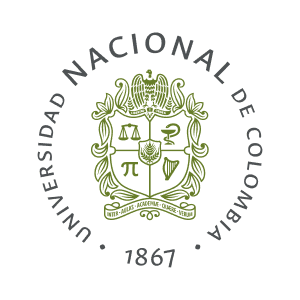

# Proyecto NLP

## Título:
Similitudes y Conexiones entre Papers

## Estudiantes:
- Angel David Pineros Sierra
- Miller Estiven Barrera Gonzalez
- Juan David Rodriguez Gomez
- Fabio Esteban Murcia Martínez

## Repositorio del Proyecto:
[https://github.com/mbarrerag/NLP-Dataset.git](https://github.com/mbarrerag/NLP-Dataset.git)

In [2]:
import pandas as pd
import os

# Clone the GitHub repository
!git clone https://github.com/mbarrerag/NLP-Dataset.git

fatal: destination path 'NLP-Dataset' already exists and is not an empty directory.


In [2]:
import re, json, html, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display


In [3]:
# Define necessary variables for the cleaning process
from pathlib import Path

DATASET_NAME = 'HORUS_Bogota_Ingenieria_Ingles.xlsx'
DATASET_CANDIDATES = [
    Path('data/raw') / DATASET_NAME,
    Path('NLP-Dataset/data/raw') / DATASET_NAME,
    Path('NLP-Dataset') / DATASET_NAME,
]
dataset_path = next((path for path in DATASET_CANDIDATES if path.is_file()), DATASET_CANDIDATES[0])
if not dataset_path.is_file():
    raise FileNotFoundError(f'Dataset not found. Checked: {DATASET_CANDIDATES}')

SIMILARITY_METHOD = 'tfidf'
RANDOM_SEED = 42          # semilla común: Doc2Vec, k-means, UMAP y t-SNE
OUTPUT_DIR = 'output'
INPUT_FILE = dataset_path
SHEET_NAME = None

In [4]:
# Load the dataset using the configured file path and worksheet
sheet = 0 if SHEET_NAME is None else SHEET_NAME
df = pd.read_excel(INPUT_FILE, sheet_name=sheet)
print(f"Successfully loaded dataset from: {INPUT_FILE}")
display(df.head(10))

Successfully loaded dataset from: NLP-Dataset/HORUS_Bogota_Ingenieria_Ingles.xlsx


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace
0,Post-harvest evaluation of the effect of folia...,NaN,Plant Signaling & Behavior,"Florez Roncancio Victor Julio, Darghan Contrer...",10.1080/15592324.2025.2465234,NaN,15592316,0.0,Inglés,31/12/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
1,Prebiotic potential of cocoa bean shells in fo...,NaN,Cogent Food & Agriculture,"Botina Azain Blanca Lucia, Montoya Campuzano O...",10.1080/23311932.2025.2536915,NaN,23311932,0.0,Inglés,31/12/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
2,Exploring microbial soil communities structure...,NaN,Cogent Food & Agriculture,"Saavedra Correa, Juan David, Aristizabal Gutie...",10.1080/23311932.2025.2548928,NaN,23311932,0.0,Inglés,31/12/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
3,Recent advances in solvent development for car...,"The practices of carbon capture, storage, and ...",Separation and Purification Technology,"Vargas Sáenz Julio Cesar, Castro Juan Jose, Qu...",10.1016/j.seppur.2025.134962,NaN,"13835866, 18733794",1.0,Inglés,31/12/2025,Estado del arte,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
4,Effect of the conformation of a diazoted-resor...,"In the present work, a mono-diazoted resorcin[...",Journal of Molecular Structure,"Maldonado Villamil Mauricio, López Mónica, Est...",10.1016/j.molstruc.2025.143311,NaN,00222860,0.0,Inglés,15/12/2025,Artículo de revista,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
5,Study of Tm3+ incorporation in TiO2 coatings f...,"In this work, the synthesis and characterizati...",Applied Surface Science,"Torres Ceron Darwin Augusto, Restrepo Parra El...",10.1016/j.apsusc.2025.164338,NaN,01694332,0.0,Inglés,15/12/2025,Artículo de revista,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
6,Tuning confined states in Si1−xGex photonic ca...,"In this work, using the transfer matrix method...","Physica . B , Condensed Matter","Vinck Posada Herbert, Francis Segovia Chaves, ...",10.1016/j.physb.2025.417984,NaN,09214526,0.0,Inglés,15/12/2025,Artículo de revista,SCOPUS,https://dx.doi.org/10.1016/j.physb.2025.417984...
7,The NW-Amazonian Craton in Colombia: A Paleo-M...,The geological evolution of the NW-Amazonian C...,Journal of South American Earth Sciences,"Cramer Thomas Heinrich, Amed Bonilla, Hernánde...",10.1016/j.jsames.2025.105806,NaN,08959811,0.0,Inglés,15/12/2025,Estado del arte,SCOPUS,https://dx.doi.org/10.1016/j.jsames.2025.10580...
8,Scientometric analysis of computational calcul...,The rapid industrialization has driven economi...,Global Journal of Environmental Science and Ma...,"Torres Ceron Darwin Augusto, Restrepo Parra El...",10.22034/gjesm.2025.01.18,NaN,"23833866, 23833572",1.0,Inglés,01/12/2025,Artículo de revista,SCOPUS,https://dx.doi.org/10.22034/gjesm.2025.01.18 ...
9,Transition clinics in pediatric rheumatology i...,Introduction: Transition clinics are conceived...,Advances in Rheumatology,"Quintana López Gerardo, Ramirez Lauren Natalia...",10.1186/s42358-024-00419-2,NaN,25233106,0.0,Inglés,01/12/2025,Estado del arte,SCOPUS,https://www.scopus.com/inward/record.uri?partn...


#Columas del dataset

*   **`paper_id`**: Un identificador único generado para cada registro, comenzando con `HORUS_` seguido de un número secuencial.
*   **`title_normalized`**: Una versión normalizada del `Título original`, convertida a minúsculas y limpiada de caracteres especiales.
*   **`abstract_clean`**: Una versión limpia de la `Descripción original` (abstract), donde se eliminan etiquetas HTML y se normaliza el espacio en blanco.
*   **`abstract_status`**: Indica si el abstract está presente (`PRESENT`) o si falta (`MISSING_ABSTRACT`).
*   **`journal_normalized`**: Una versión limpia de la columna `Revista / Conferencia`.
*   **`doi_normalized`**: El DOI (Digital Object Identifier) de la publicación, extraído y normalizado para asegurar un formato consistente.
*   **`issn_normalized`**: El ISSN (International Standard Serial Number) de la publicación, extraído y normalizado.
*   **`language_iso639_1`** o **`idioma normalizado`**: El idioma de la publicación, mapeado a su código ISO 639-1 (ej., `en` para inglés, `es` para español). Si el idioma no se reconoce, se etiqueta como `und` (undetermined) o el texto original en mayúsculas.
*   **`document_type_normalized`**: El tipo de documento (ej., `JOURNAL_ARTICLE`, `CONFERENCE_PAPER`), normalizado a un conjunto de categorías predefinidas. Si no se reconoce, se etiqueta como `OTHER`.
*   **`source_normalized`**: La fuente de la publicación (ej., `WEB_OF_SCIENCE`, `SCOPUS`), normalizada a un conjunto de categorías predefinidas. Si no se reconoce, se etiqueta como `UNKNOWN`.
*   **`publication_date`**: La fecha de publicación, convertida al formato `YYYY-MM-DD`.
*   **`publication_year`**: El año de publicación, extraído de la fecha de publicación.
*   **`citations_normalized`**: El número de citaciones, convertido a formato numérico entero y con valores faltantes llenados con 0.
*   **`authors_normalized`**: Una lista de autores, donde los nombres se limpian y se separan adecuadamente.
*   **`authors_normalized_text`**: Una cadena de texto que concatena los autores normalizados, separados por ` | `.
*   **`text_for_nlp`**: Un campo combinado del título normalizado y el abstract limpio, diseñado para ser utilizado en tareas de procesamiento de lenguaje natural (NLP).

## Valores nulos

In [5]:
# Contar los valores nulos iniciales en el DataFrame 'df' (el DataFrame original cargado)
print("Valores nulos por columna en el DataFrame inicial:")
display(df.isnull().sum())

Valores nulos por columna en el DataFrame inicial:


Título original              0
Descripción original      1478
Revista / Conferencia     6754
Coautores                    0
Doi                      13846
ISBN                     23331
ISSN                     13568
Citaciones                1496
Idioma                       0
Fecha                        0
Tipo                         0
Fuente                       0
Enlace                   10701
dtype: int64

## Posibles duplicados

In [6]:
# Encontrar y eliminar registros con el mismo 'Título original', 'Descripción original' y 'Fecha'
duplicate_subset = ['Título original', 'Descripción original']
duplicate_mask = df.duplicated(subset=duplicate_subset, keep=False)
duplicate_titles_abstracts = df.loc[duplicate_mask].copy()

if not duplicate_titles_abstracts.empty:
    print(f"Se encontraron {len(duplicate_titles_abstracts)} registros que pertenecen a grupos duplicados:")
    display(duplicate_titles_abstracts.sort_values(by=duplicate_subset))
    rows_before = len(df)
    df = df.drop_duplicates(subset=duplicate_subset, keep='first').copy()
    print(f"Se eliminaron {rows_before - len(df)} duplicados; quedan {len(df)} registros.")
else:
    print("No se encontraron registros duplicados.")

Se encontraron 117 registros que pertenecen a grupos duplicados:


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace
844,A Potassium Phosphite Solution as a Dual-Actio...,NaN,Horticulturae,"Saldarriaga Gómez, Catalina, González Almario ...",10.3390/horticulturae11050462,NaN,NaN,0.0,Inglés,25/04/2025,Artículo de revista,WEB OF SCIENCE,https://dx.doi.org/10.3390/horticulturae110504...
2148,A Potassium Phosphite Solution as a Dual-Actio...,NaN,Preprints,"Saldarriaga Gómez, Catalina, González Almario ...",10.20944/preprints202502.0717.v1,NaN,NaN,0.0,Inglés,01/01/2025,Preimpresión,WEB OF SCIENCE,https://dx.doi.org/10.20944/preprints202502.07...
21590,BIOPOLIS 2024: Living landscapes and infrastru...,--,NaN,"Ibañez Gutierrez Ricardo Andres, Magda Sofia J...",NaN,NaN,NaN,NaN,Inglés,01/01/2022,Proyecto,HERMES,NaN
21593,BIOPOLIS 2024: Living landscapes and infrastru...,--,NaN,"Chica Segovia Angelica, Ibañez Gutierrez Ricar...",NaN,NaN,NaN,NaN,Inglés,01/01/2022,Proyecto,HERMES,NaN
2278,COMPETENT: A Game for Teaching Competencies Re...,NaN,IEEE Revista Iberoamericana de Tecnologías del...,"Maturana González Grissa Vianney, Zapata Jaram...",10.1109/RITA.2024.3497832,NaN,NaN,0.0,Inglés,01/01/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
518,presentation,NaN,"Literatura : Teoría , História , Crítica",Diaz Villarreal William Fernando,NaN,NaN,"01235931, 22565450",0.0,Inglés,01/07/2025,Artículo de revista,RevistasUNAL,https://revistas.unal.edu.co/index.php/lthc/ar...
579,presentation,NaN,Ideas y Valores,"Sanclemente Andrea Lehner, Gama Barbosa Luis E...",NaN,NaN,"20113668, 01200062",0.0,Inglés,29/06/2025,Artículo de revista,RevistasUNAL,https://revistas.unal.edu.co/index.php/idval/a...
10312,presentation,NaN,Forma y Funcion,"Sichra Inge, Robayo Romero Camilo Alberto",NaN,NaN,"0120338X, 22565469",0.0,Inglés,06/07/2023,Artículo de revista,RevistasUNAL,https://revistas.unal.edu.co/index.php/formayf...
11511,• • • • • • • • • • • • • • • • • • • • • • • ...,Not reported,NaN,Cardenas Agudelo Maria Fernanda,NaN,NaN,NaN,0.0,Inglés,14/04/2023,Tesis Maestría,SARA,NaN


Se eliminaron 90 duplicados; quedan 24910 registros.


## 1. Limpieza bibliográfica

Conservamos las columnas originales y añadimos campos normalizados. Los abstracts vacíos se marcan; nunca se inventa contenido.

In [7]:
Path(OUTPUT_DIR).mkdir(exist_ok=True)

def clean_text(x, lower=False):
    if pd.isna(x): return ''
    x = re.sub(r'<[^>]+>', ' ', html.unescape(str(x)))
    x = re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', x)).strip()
    return x.lower() if lower else x
def norm_doi(x):
    x = re.sub(r'^(https?://(dx\.)?doi\.org/|doi:\s*)', '', clean_text(x, True))
    m = re.search(r'10\.\d{4,9}/[-._;()/:a-z0-9]+', x)
    return m.group(0).rstrip('.,;)') if m else ''
def norm_issn(x):
    d = re.sub(r'[^0-9Xx]', '', clean_text(x).replace('.0','')).upper()
    return f'{d[:4]}-{d[4:]}' if len(d) == 8 else clean_text(x)
LANG={'inglés':'en','ingles':'en','english':'en','español':'es','espanol':'es','spanish':'es','portugués':'pt','portugues':'pt','portuguese':'pt','francés':'fr','frances':'fr','french':'fr','alemán':'de','aleman':'de','german':'de','italiano':'it','catalán':'ca','galicia':'gl','vasco':'eu','indonesio':'id'}
TYPE={'artículo de revista':'JOURNAL_ARTICLE','articulo de revista':'JOURNAL_ARTICLE','artículo de conferencia':'CONFERENCE_PAPER','articulo de conferencia':'CONFERENCE_PAPER','ponencias en eventos especializados':'CONFERENCE_PRESENTATION','capítulo de libro':'BOOK_CHAPTER','capitulo de libro':'BOOK_CHAPTER','libro':'BOOK','tesis maestría':'MASTER_THESIS','tesis doctorado':'DOCTORAL_THESIS','tesis especialización':'SPECIALIZATION_THESIS','estado del arte':'LITERATURE_REVIEW','preimpresión':'PREPRINT','preimpresion':'PREPRINT','patente':'PATENT','proyecto':'PROJECT','editorial':'EDITORIAL','formato audiovisual':'AUDIOVISUAL'}
SOURCE={'web of science':'WEB_OF_SCIENCE','wos':'WEB_OF_SCIENCE','scopus':'SCOPUS','pubmed':'PUBMED','scielo':'SCIELO','repositoriounal':'REPOSITORIO_UNAL','revistasunal':'REVISTAS_UNAL','bibliotecasunal':'BIBLIOTECAS_UNAL','sara':'SARA','hermes':'HERMES'}
def norm_map(x, mapping, empty):
    k=clean_text(x,True); return mapping.get(k, empty if not k else k.upper().replace(' ','_'))
def parse_authors(x):
    raw=clean_text(x)
    if not raw:return []
    parts=[clean_text(a) for a in (raw.split(';') if ';' in raw else raw.split(','))] # Changed to handle multiple delimiters
    out=[];i=0
    while i<len(parts):
        a=parts[i]
        if a and len(a.split())==1 and i+1<len(parts): a=f'{a}, {parts[i+1]}';i+=1
        if a:out.append(a)
        i+=1
    return out

raw = df.copy()
expected={'Título original','Descripción original','Revista / Conferencia','Coautores','Doi','ISSN','Citaciones','Idioma','Fecha','Tipo','Fuente','Enlace'}
if missing:=expected-set(raw.columns):raise ValueError(f'Faltan: {sorted(missing)}')
papers=raw.copy();papers.insert(0,'paper_id',[f'HORUS_{i:06d}' for i in range(1,len(papers)+1)])

# Eliminar la columna 'Doi ISBN'
papers = papers.drop(columns=['Doi ISBN'], errors='ignore')
# Eliminar la columna 'ISBN'
papers = papers.drop(columns=['ISBN'], errors='ignore')

papers['title_normalized']=papers['Título original'].map(lambda x:clean_text(x,True));papers['abstract_clean']=papers['Descripción original'].map(clean_text)
papers['abstract_status']=np.where(papers.abstract_clean.eq(''),'MISSING_ABSTRACT','PRESENT');papers['journal_normalized']=papers['Revista / Conferencia'].map(clean_text)
papers['doi_normalized']=papers.Doi.map(norm_doi);papers['issn_normalized']=papers.ISSN.map(norm_issn);papers['language_iso639_1']=papers.Idioma.map(lambda x:LANG.get(clean_text(x,True),'und' if not clean_text(x,True) else clean_text(x,True)))
papers['Idioma original'] = papers['Idioma']
papers = papers.drop(columns=['Idioma'], errors='ignore')
papers['document_type_normalized']=papers.Tipo.map(lambda x:norm_map(x,TYPE,'OTHER'));papers['source_normalized']=papers.Fuente.map(lambda x:norm_map(x,SOURCE,'UNKNOWN'))
date=pd.to_datetime(papers.Fecha,dayfirst=True,errors='coerce');papers['publication_date']=date.dt.strftime('%Y-%m-%d').fillna('');papers['publication_year']=date.dt.year.astype('Int64')
papers['citations_normalized']=pd.to_numeric(papers.Citaciones,errors='coerce').fillna(0).astype(int);papers['authors_normalized']=papers.Coautores.map(parse_authors);papers['authors_normalized_text']=papers.authors_normalized.map(' | '.join)
papers['text_for_nlp']=(papers.title_normalized+'. '+papers.abstract_clean.map(lambda x:clean_text(x,True))).str.strip('. ')
papers['dedup_key']=np.where(papers.doi_normalized.ne(''),'DOI:'+papers.doi_normalized,'TITLE_YEAR:'+papers.title_normalized+'|'+papers.publication_year.astype(str));papers['duplicate_group']=papers.groupby('dedup_key',sort=False).ngroup().map(lambda x:f'DUP_{x:06d}');papers['is_duplicate']=papers.duplicated('dedup_key',keep='first')
print(f'Registros: {len(papers):,} | Sin resumen: {papers.abstract_status.eq("MISSING_ABSTRACT").sum():,} | Duplicados: {papers.is_duplicate.sum():,}')
papers = papers.drop(columns=['is_duplicate'], errors='ignore')
papers = papers.drop(columns=['dedup_key', 'duplicate_group'], errors='ignore')
display(papers[['paper_id','Título original','doi_normalized','language_iso639_1','document_type_normalized','abstract_status']].head())

Registros: 24,910 | Sin resumen: 1,405 | Duplicados: 646


,paper_id,Título original,doi_normalized,language_iso639_1,document_type_normalized,abstract_status
0,HORUS_000001,Post-harvest evaluation of the effect of folia...,10.1080/15592324.2025.2465234,en,JOURNAL_ARTICLE,MISSING_ABSTRACT
1,HORUS_000002,Prebiotic potential of cocoa bean shells in fo...,10.1080/23311932.2025.2536915,en,JOURNAL_ARTICLE,MISSING_ABSTRACT
2,HORUS_000003,Exploring microbial soil communities structure...,10.1080/23311932.2025.2548928,en,JOURNAL_ARTICLE,MISSING_ABSTRACT
3,HORUS_000004,Recent advances in solvent development for car...,10.1016/j.seppur.2025.134962,en,LITERATURE_REVIEW,PRESENT
4,HORUS_000005,Effect of the conformation of a diazoted-resor...,10.1016/j.molstruc.2025.143311,en,JOURNAL_ARTICLE,PRESENT


### Duplicados por DOI o título

La deduplicación de la exploración solo elimina registros con el mismo título, descripción y fecha, y distingue mayúsculas: no detecta el mismo artículo repetido con el título en MAYÚSCULAS, con signos distintos (`¿`, `–`) o con otra fecha. La limpieza anterior ya calculaba estos duplicados (`Duplicados: 677`) pero no los eliminaba, y la similitud TF-IDF los detectó después como pares con similitud cercana a 1.

**Criterio:** dos registros son el mismo artículo si comparten **DOI**; si no tienen DOI, si comparten el **título** (sin mayúsculas ni signos) y el **año**. De cada grupo se conserva el que tiene abstract (y, a igualdad, el primero). Los eliminados se registran en `output/duplicates_removed.csv` con el `paper_id` que se conservó.

**Limitación:** en 31 grupos el registro conservado fue luego descartado por el filtro de idioma (tenía un abstract de relleno como `Not reported`, que aquí cuenta como abstract), de modo que como mucho se pierden 31 artículos (0,15 % del corpus). Deduplicar después del filtro de idioma evitaría este caso.

In [8]:
DUPLICATES_OUTPUT_FILE = Path(OUTPUT_DIR) / 'duplicates_removed.csv'


def title_key(title):
    """Título sin mayúsculas ni signos: 'MODELING X.' y 'Modeling x' dan la misma clave."""
    return re.sub(r'[^a-z0-9]+', ' ', str(title).lower()).strip()


has_doi = papers['doi_normalized'].ne('')
dedup_key = pd.Series(
    np.where(has_doi, 'DOI:' + papers['doi_normalized'],
             'TITLE:' + papers['title_normalized'].map(title_key) + '|' + papers['publication_year'].astype(str)),
    index=papers.index)

# Al ordenar antes, el registro con abstract es el que se conserva.
order = np.argsort(~papers['abstract_status'].eq('PRESENT').to_numpy(), kind='stable')
is_duplicate = pd.Series(dedup_key.iloc[order].duplicated().to_numpy(), index=papers.index[order]).reindex(papers.index)

kept_id = papers.loc[~is_duplicate, 'paper_id'].set_axis(dedup_key[~is_duplicate])
removed = papers.loc[is_duplicate, ['paper_id', 'Título original', 'doi_normalized']].copy()
removed['criterion'] = np.where(has_doi[is_duplicate], 'DOI', 'TITLE_YEAR')
removed['kept_paper_id'] = dedup_key[is_duplicate].map(kept_id).to_numpy()
removed.to_csv(DUPLICATES_OUTPUT_FILE, index=False, encoding='utf-8-sig')

rows_before = len(papers)
papers = papers.loc[~is_duplicate].reset_index(drop=True)
print(f'Registros antes: {rows_before:,} | duplicados eliminados: {len(removed):,} | quedan: {len(papers):,}')
print(removed['criterion'].value_counts().rename('eliminados').to_string())
print(f'Detalle de eliminados: {DUPLICATES_OUTPUT_FILE}')
display(removed.head(10))

Registros antes: 24,910 | duplicados eliminados: 653 | quedan: 24,257
criterion
DOI           620
TITLE_YEAR     33
Detalle de eliminados: output/duplicates_removed.csv


,paper_id,Título original,doi_normalized,criterion,kept_paper_id
759,HORUS_000759,Editorial,,TITLE_YEAR,HORUS_000751
795,HORUS_000795,Editorial,,TITLE_YEAR,HORUS_000751
845,HORUS_000845,Editorial,,TITLE_YEAR,HORUS_000751
1031,HORUS_001029,CO2 ENRICHMENT IN PROTECTED AGRICULTURE: A SYS...,10.3390/su17072809,DOI,HORUS_000940
1124,HORUS_001122,Geographic perspectives on sustainability: Tow...,10.1016/j.envdev.2024.101121,DOI,HORUS_001023
1127,HORUS_001125,Advances and challenges on hydrothermal proces...,10.1016/j.biombioe.2025.107621,DOI,HORUS_001062
1341,HORUS_001339,Use of Lighting Technology in Controlled and S...,10.3390/su17041712,DOI,HORUS_001250
1385,HORUS_001383,Psychoanalysis as Social and Political Discour...,10.1057/s41282-024-00509-6,DOI,HORUS_001386
1386,HORUS_001384,"APOE4, ALZHEIMER¿S AND PERIODONTAL DISEASE: A ...",10.1016/j.arr.2024.102649,DOI,HORUS_001124
1410,HORUS_001407,IMMUNE THROMBOCYTOPENIA POSSIBLY TRIGGERED BY ...,10.1590/s1678-9946202567001,DOI,HORUS_001403


## Filtro de idioma: solo artículos en inglés

Para que todo el corpus esté en las mismas condiciones, se conservan **solo los artículos con título y abstract en inglés**. Cada artículo eliminado queda registrado con su motivo en `output/dropped_papers.csv`; el Excel original no se modifica.

| Motivo | Criterio |
|---|---|
| `NO_ABSTRACT` | Abstract vacío, marcador (`Not reported`, `--`, `No Reportado`, `Not applicable`…) o idéntico al título. Sin abstract no hay idioma confiable ni texto suficiente para comparar. |
| `NOT_ENGLISH` | El idioma del documento completo (título + abstract), detectado con langid, no es inglés. |
| `TITLE_NOT_TRANSLATED` | El abstract está en inglés pero el título quedó en español. |

**Por qué no se usa la tabla de idiomas por título** (celda de langid al final): langid falla con títulos cortos, en MAYÚSCULAS o con nombres científicos (`Observation of the B0 → D̄*0K+π- decays` sale `la`; `STAPHYLOCOCCUS AUREUS IN PEDIATRIA` sale `it`). Filtrar por idioma del título eliminaría ~650 artículos que sí están en inglés. Aquí langid se aplica al documento completo y se restringe a idiomas plausibles del corpus.

In [9]:
# langid, spaCy y en_core_web_sm; en Colab spaCy y el modelo ya vienen instalados.
!pip install -q langid spacy
!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [10]:
import re
from pathlib import Path

import pandas as pd
from langid.langid import LanguageIdentifier, model as langid_model
from spacy.lang.en.stop_words import STOP_WORDS as ENGLISH_STOP_WORDS
from spacy.lang.es.stop_words import STOP_WORDS as SPANISH_STOP_WORDS

TARGET_LANGUAGE = 'en'
TITLE_COLUMN = 'Título original'
ABSTRACT_COLUMN = 'abstract_clean'
# Restringir langid a los idiomas plausibles evita falsos 'la', 'af', 'eo' por nombres científicos.
CANDIDATE_LANGUAGES = ['en', 'es', 'pt', 'fr', 'it', 'de']
MIN_SPANISH_MARKERS_IN_TITLE = 2
DROPPED_OUTPUT_FILE = Path(OUTPUT_DIR) / 'dropped_papers.csv'

# Abstracts que solo marcan "sin resumen".
PLACEHOLDER_ABSTRACT_RE = re.compile(
    r'^\W*(?:not? reported|unreported|no reportado|not applicable|no aplica|not specified|not available'
    r'|no summary|no abstract|no information|n/?a|editorial|\d+)?\W*$',
    flags=re.IGNORECASE,
)

# Stopwords exclusivas de cada idioma: "huella" para detectar títulos sin traducir.
# Se excluyen las que chocan con símbolos químicos o siglas en inglés ('Ni', 'Si', 'Se', 'Al').
MARKER_EXCLUSIONS = {'ni', 'si', 'se', 'mi', 'ti', 'te', 'os', 'al', 'sin', 'con'}
SPANISH_MARKERS = (SPANISH_STOP_WORDS - ENGLISH_STOP_WORDS) - MARKER_EXCLUSIONS
ENGLISH_MARKERS = ENGLISH_STOP_WORDS - SPANISH_STOP_WORDS
WORD_RE = re.compile(r'[a-záéíóúñü]+', flags=re.IGNORECASE)

document_identifier = LanguageIdentifier.from_modelstring(langid_model, norm_probs=True)
document_identifier.set_languages(CANDIDATE_LANGUAGES)
title_identifier = LanguageIdentifier.from_modelstring(langid_model, norm_probs=True)
title_identifier.set_languages([TARGET_LANGUAGE, 'es'])


def has_real_abstract(title, abstract):
    abstract = abstract.strip()
    return not PLACEHOLDER_ABSTRACT_RE.match(abstract) and abstract.lower() != title.strip().lower()


def is_untranslated_title(title):
    """Título con más stopwords exclusivas del español que del inglés y que langid (en/es) clasifica como español."""
    words = WORD_RE.findall(title.lower())
    spanish = sum(w in SPANISH_MARKERS for w in words)
    english = sum(w in ENGLISH_MARKERS for w in words)
    if spanish < MIN_SPANISH_MARKERS_IN_TITLE or spanish <= english:
        return False
    return title_identifier.classify(title.lower())[0] == 'es'


def drop_reason(title, abstract):
    """Motivo para eliminar el artículo, o None si se conserva."""
    title, abstract = clean_text(title), clean_text(abstract)
    if not has_real_abstract(title, abstract):
        return 'NO_ABSTRACT'
    if document_identifier.classify(f'{title}. {abstract}'.lower())[0] != TARGET_LANGUAGE:
        return 'NOT_ENGLISH'
    if is_untranslated_title(title):
        return 'TITLE_NOT_TRANSLATED'
    return None

In [11]:
papers['drop_reason'] = [drop_reason(t, a) for t, a in zip(papers[TITLE_COLUMN], papers[ABSTRACT_COLUMN])]

total_before = len(papers)
dropped = papers.loc[papers['drop_reason'].notna(), ['paper_id', 'drop_reason', TITLE_COLUMN, ABSTRACT_COLUMN]]
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
dropped.to_csv(DROPPED_OUTPUT_FILE, index=False, encoding='utf-8-sig')

papers = papers.loc[papers['drop_reason'].isna()].drop(columns=['drop_reason']).reset_index(drop=True)

print(f'Artículos antes del filtro: {total_before:,}')
print(dropped['drop_reason'].value_counts().rename('eliminados').to_string())
print(f'Artículos en inglés que se conservan: {len(papers):,} ({len(papers) / total_before:.1%})')
print(f'Detalle de eliminados: {DROPPED_OUTPUT_FILE}')
display(dropped.loc[dropped['drop_reason'].ne('NO_ABSTRACT')].head(10))

Artículos antes del filtro: 24,257
drop_reason
NO_ABSTRACT             4068
TITLE_NOT_TRANSLATED     120
NOT_ENGLISH               18
Artículos en inglés que se conservan: 20,051 (82.7%)
Detalle de eliminados: output/dropped_papers.csv


,paper_id,drop_reason,Título original,abstract_clean
1426,HORUS_001438,TITLE_NOT_TRANSLATED,"CONTAMINACIÓN EN SEDIMENTOS POR METALES (AS, C...",Metals are pollutants released into the enviro...
2402,HORUS_002433,TITLE_NOT_TRANSLATED,COLONIALIDAD TERRITORIAL Y TURISMO COMO ESTRAT...,This article addresses the understanding of co...
2628,HORUS_002669,TITLE_NOT_TRANSLATED,DESARROLLO DE PANELES ACÚSTICO CONSIDERANDO ES...,This article presents a study on the impact of...
2718,HORUS_002765,TITLE_NOT_TRANSLATED,ACTUALIZACIÓN DE INFORMACIÓN ESTRUCTURAL DE UN...,Modeling the orientation of data obtained from...
2861,HORUS_002917,TITLE_NOT_TRANSLATED,SERPIENTES ACUÁTICAS DE IMPORTANCIA MÉDICA EN ...,"Since 2008, reporting snakebite accidents has ..."
3108,HORUS_003175,NOT_ENGLISH,Virtual space: architecture as a mediation bet...,This dissertation is a philosophical and aesth...
3533,HORUS_003614,TITLE_NOT_TRANSLATED,EFECTO DEL BIAS DEL SUSTRATO Y LA PRESIÓN DE T...,"In this study, TiAlZrTaNb nitride thin films w..."
3766,HORUS_003861,NOT_ENGLISH,Model of virtual teaching-learning environment...,Es el Higher Education Institutions (IES) adva...
3816,HORUS_003914,TITLE_NOT_TRANSLATED,EFECTO DE LOS MÉTODOS DE CONSERVACIÓN SOBRE LA...,Introduction: Colostrum contains a large numbe...
4047,HORUS_004151,NOT_ENGLISH,LEVEL OF ENDOTHELIN 1 (ET-1) IN CHILDREN WITH ...,SE PRESENTAN LOS RESULTADOS DE UN TRABAJO DE I...


## Tokenización, stopwords y lematización (entrada para TF-IDF y Doc2Vec)

**Entrada:** `Título original` + `abstract_clean` de los artículos en inglés que pasaron el filtro, con sus mayúsculas originales. No se usa `text_for_nlp` porque está en minúsculas y spaCy etiqueta y lematiza peor sin ellas.

**Pasos:**
1. **Limpieza de plantilla:** `(text taken from the source)` y sus variantes (Repositorio UNAL), copyright de editoriales, `[figure not available]`, encabezados de sección (`Methods and Results:`), marcadores filtrados por la traducción (`__KEEP0_`) y apóstrofos corruptos (`furnace¿s`). Los títulos en MAYÚSCULAS o *Title Case* se pasan a minúsculas para que spaCy no los trate como nombres propios.
2. **Tokenización** con spaCy (`en_core_web_sm`).
3. **Eliminación de stopwords:** lista general de spaCy + vocabulario de plantilla académica (`DOMAIN_STOPWORDS`) + palabras función del español que puedan quedar (`de`, `la`), números, puntuación, URLs, correos e iniciales/abreviaturas (`P.`, `e.g.`).
4. **Lematización:** `networks → network`, `trained → train`. Se prefiere sobre stemming porque los términos quedan legibles (`computing → compute` vs. `comput`), lo que importa para interpretar TF-IDF y para los nodos del KAG. Stemming disponible con `NORMALIZATION = 'stem'`.

**Salidas:**
- `papers['text_tokens']`: tokens unidos por espacio → entrada directa de `TfidfVectorizer`.
- `output/tokens.parquet`: listas de tokens por `paper_id` → entrada de Doc2Vec.

> Los **Sentence Embeddings no usan esta salida**: tienen su propio tokenizador (subword) y necesitan el texto completo con contexto.

In [12]:
import time
from collections import Counter

import spacy

# 'lemma' (recomendado: términos legibles para TF-IDF/KAG) o 'stem' (Snowball: rápido, menos legible)
NORMALIZATION = 'lemma'

SPACY_MODEL = 'en_core_web_sm'
SPACY_DISABLE = ['parser', 'ner']      # no se necesitan para lematizar; ahorran tiempo
SPACY_BATCH_SIZE = 256
SPACY_N_PROCESS = 1                    # subir a 2 en Colab si hay RAM suficiente
MIN_TOKEN_LEN = 2
TOKENS_OUTPUT_FILE = Path(OUTPUT_DIR) / 'tokens.parquet'

# Stopwords de dominio: vocabulario de "plantilla" académica presente en casi todos los abstracts.
# Se comparan contra el término ya normalizado. Revisar con la celda de inspección y ampliar.
DOMAIN_STOPWORDS = {
    'study', 'paper', 'article', 'work', 'result', 'present', 'propose', 'show', 'use', 'aim',
    'objective', 'conclusion', 'finding', 'base', 'include', 'provide', 'allow', 'obtain',
    'different', 'find', 'perform', 'report', 'describe', 'carry', 'also', 'however', 'thus',
    'vs', 'etc', 'et', 'al',
    'colombia', 'colombian',   # todo el corpus es de la UNAL: no distingue unos artículos de otros
}

# Palabras función del español que puedan quedar en el texto. Solo en minúscula, para no borrar
# símbolos químicos ('Se', 'Ni') ni siglas.
SPANISH_FUNCTION_WORDS = {
    'de', 'del', 'la', 'las', 'el', 'los', 'lo', 'un', 'una', 'unos', 'unas', 'en', 'para', 'por',
    'con', 'sin', 'que', 'se', 'su', 'sus', 'como', 'sobre', 'entre', 'desde', 'hasta', 'hacia',
    'según', 'es', 'fue', 'ser', 'está', 'este', 'esta', 'estos', 'estas', 'ese', 'esa', 'le', 'les',
}

# Correcciones puntuales del lematizador de spaCy.
LEMMA_OVERRIDES = {'datum': 'data', 'dos': 'dose'}

# Marcas de repositorio/editorial DENTRO del texto: '(text taken from the source)' del Repositorio UNAL
# (y sus variantes de traducción y en español), figuras no disponibles, etc.
INLINE_BOILERPLATE_RE = re.compile(
    r'\(?\s*\d*\s*(?:texto?\s+)?tomado\s+(?:de|ed)l?\s+(?:l\s?a\s+)?(?:fuente|cap[ií]tulo)\s*\)?\.?'
    r'|\(\s*(?:[a-z]+\s+){0,4}from\s+(?:the\s+)?(?:source|chapter)\s*\)\.?'
    r'|(?:graphical abstract:\s*)?\[figure not available:\s*see fulltext\.?\]\.?'
    r'|(?:graphical abstract:\s*)?\(figure presented\.?\)\.?'
    r'|abstract in spanish is available with online material\.?',
    flags=re.IGNORECASE,
)
# Oraciones de copyright/licencia: no aportan contenido y crean similitudes falsas.
COPYRIGHT_SENTENCE_RE = re.compile(
    r'©|\ball rights reserved\b|\bpublished by\b|\blicensee\b|\bcreative commons\b'
    r'|\bthis is an open access article\b|\bprotected by copyright\b',
    flags=re.IGNORECASE,
)
# Encabezados de sección al inicio de oración ('Materials and methods.', 'Methods and Results:').
_HEADER = (r'(?:introduction|background|context|purpose|aims?|objectives?|materials|methods?|methodology'
           r'|design|setting|results?|findings|discussion|conclusions?|keywords|abstract|summary)')
SECTION_HEADER_RE = re.compile(rf'^{_HEADER}(?:\s+(?:and|&)\s+{_HEADER})*\s*[:.]\s*', flags=re.IGNORECASE)
# Oraciones tipo título ('Effect Of Therapeutic Ultrasound', 'INFRARED THERMOGRAPHY'): spaCy las toma
# como nombres propios y no lematiza. Se pasan a minúsculas si la mayoría de palabras largas empieza en mayúscula.
TITLE_LIKE_MIN_WORDS = 3
TITLE_LIKE_MIN_SHARE = 0.8
LONG_WORD_RE = re.compile(r'[^\W\d_]{4,}')
# Marcadores internos que dejó la traducción automática ('__KEEP0_', '_KEEP1__').
TRANSLATION_ARTIFACT_RE = re.compile(r'_*KEEP\d*_*')
# Apóstrofo corrupto en la fuente: 'furnace¿s' -> "furnace's".
BROKEN_APOSTROPHE_RE = re.compile(r'(?<=\w)¿(?=\w)')
SENTENCE_SPLIT_RE = re.compile(r'(?<=[.!?;])\s+')
# Abreviaturas e iniciales: 'p.' (P. aeruginosa), 'e.g.', 'i.e.'.
ABBREVIATION_RE = re.compile(r'^(?:[a-z]\.)+[a-z]?\.?$')

nlp = spacy.load(SPACY_MODEL, disable=SPACY_DISABLE)
SPACY_STOP_WORDS = nlp.Defaults.stop_words

if NORMALIZATION == 'stem':
    from nltk.stem.snowball import SnowballStemmer
    _stemmer = SnowballStemmer('english')
elif NORMALIZATION != 'lemma':
    raise ValueError(f"NORMALIZATION debe ser 'lemma' o 'stem', no {NORMALIZATION!r}")

In [13]:
def is_title_like(sentence):
    words = LONG_WORD_RE.findall(sentence)
    if len(words) < TITLE_LIKE_MIN_WORDS:
        return False
    return sum(w[0].isupper() for w in words) / len(words) >= TITLE_LIKE_MIN_SHARE


def prepare_text(text):
    """Quita plantilla (repositorio, copyright, encabezados, artefactos de traducción) y normaliza
    oraciones tipo título. Idempotente."""
    if not isinstance(text, str):
        return ''
    text = INLINE_BOILERPLATE_RE.sub('. ', TRANSLATION_ARTIFACT_RE.sub(' ', text))
    text = BROKEN_APOSTROPHE_RE.sub("'", text)
    prepared = []
    for sentence in SENTENCE_SPLIT_RE.split(text):
        sentence = SECTION_HEADER_RE.sub('', sentence.strip())
        if not sentence or COPYRIGHT_SENTENCE_RE.search(sentence):
            continue
        prepared.append(sentence.lower() if is_title_like(sentence) else sentence)
    return ' '.join(prepared).strip(' .')


def build_document(title, abstract):
    """Título + abstract ya limpios, como un solo texto."""
    parts = (prepare_text(clean_text(title)), prepare_text(clean_text(abstract)))
    return '. '.join(part for part in parts if part)


def normalize_token(tok):
    """Devuelve el término normalizado o None si el token debe descartarse."""
    if tok.is_stop or tok.is_punct or tok.is_space or tok.like_num or tok.like_url or tok.like_email:
        return None
    if tok.text.islower() and tok.lower_ in SPANISH_FUNCTION_WORDS:
        return None
    term = tok.lemma_.lower() if NORMALIZATION == 'lemma' else _stemmer.stem(tok.lower_)
    if ABBREVIATION_RE.match(term):
        return None
    term = term.strip("-'’_.")
    term = LEMMA_OVERRIDES.get(term, term)
    if len(term) < MIN_TOKEN_LEN or not any(c.isalpha() for c in term):
        return None
    if term in SPACY_STOP_WORDS or term in DOMAIN_STOPWORDS:
        return None
    return term


def tokenize_corpus(df, title_col=TITLE_COLUMN, abstract_col=ABSTRACT_COLUMN):
    """Arma el documento (título + abstract), tokeniza, quita stopwords y normaliza con nlp.pipe."""
    texts = [build_document(t, a) for t, a in zip(df[title_col], df[abstract_col])]
    docs = nlp.pipe(texts, batch_size=SPACY_BATCH_SIZE, n_process=SPACY_N_PROCESS)
    tokens = [[t for t in (normalize_token(tok) for tok in doc) if t] for doc in docs]
    return pd.DataFrame({
        'paper_id': df['paper_id'].values,
        'tokens': tokens,
        'n_tokens': [len(t) for t in tokens],
    }, index=df.index)

In [14]:
_t0 = time.time()
tokenized = tokenize_corpus(papers)
print(f'Tokenización: {len(tokenized):,} documentos en {time.time() - _t0:,.0f} s')

papers['text_tokens'] = tokenized['tokens'].map(' '.join)    # string: entrada directa para TfidfVectorizer

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
tokenized.to_parquet(TOKENS_OUTPUT_FILE, index=False)         # listas de tokens: entrada para Doc2Vec
print(f'Guardado: {TOKENS_OUTPUT_FILE}')

Tokenización: 20,051 documentos en 464 s


Guardado: output/tokens.parquet


In [15]:
print(tokenized['n_tokens'].describe().round(1).to_string())

# Términos con mayor frecuencia documental: candidatos a DOMAIN_STOPWORDS si son "plantilla".
doc_freq = Counter(t for toks in tokenized['tokens'] for t in set(toks))
top_df = pd.DataFrame(doc_freq.most_common(40), columns=['term', 'doc_freq'])
top_df['doc_share'] = (top_df['doc_freq'] / max(len(tokenized), 1)).round(3)
display(top_df)

for idx in tokenized.index[:2]:
    print('\nANTES  :', f"{papers.at[idx, TITLE_COLUMN]}. {papers.at[idx, ABSTRACT_COLUMN]}"[:300])
    print('DESPUÉS:', papers.at[idx, 'text_tokens'][:300])

count    20051.0
mean       114.5
std         56.0
min          2.0
25%         82.0
50%        105.0
75%        142.0
max       1373.0


,term,doc_freq,doc_share
0,analysis,6496,0.324
1,high,5570,0.278
2,research,5189,0.259
3,process,5185,0.259
4,model,4674,0.233
5,system,4158,0.207
6,evaluate,4139,0.206
7,identify,3886,0.194
8,development,3859,0.192
9,data,3629,0.181



ANTES  : Recent advances in solvent development for carbon capture. The practices of carbon capture, storage, and utilization have the potential to reduce CO 2 emissions and the global temperature increase it causes. In this review, an examination of the various types of solvents utilized in absorption captu
DESPUÉS: recent advance solvent development carbon capture practice carbon capture storage utilization potential reduce co emission global temperature increase cause review examination type solvent utilize absorption capture process conduct physical solvent chemical solvent amine deep eutectic solvent ionic 

ANTES  : Effect of the conformation of a diazoted-resorcinarene on its interaction with cupric ions. In the present work, a mono-diazoted resorcin[4]arene was synthesized and characterized by FT–IR, 1 H–NMR and 13 C–NMR . The complexation between the cupric ion and said mono-diazoted resorcin[4]arene was stu
DESPUÉS: effect conformation diazote resorcinarene interaction cupri

## Similitud entre artículos con TF-IDF

**TF-IDF** da a cada término un peso alto cuando es frecuente en el artículo y raro en el resto del corpus, de modo que los términos que caracterizan a un artículo pesan más que los genéricos. Cada artículo queda representado como un vector y la **similitud entre dos artículos es el coseno** de sus vectores.

**Decisiones:**
- **Entrada:** `papers['text_tokens']`, que ya está limpio, sin stopwords y lematizado en la sección anterior. El vectorizador no vuelve a preprocesar (tokeniza solo por espacios y no pasa a minúsculas).
- **Unigramas:** se probó también con bigramas (`neural network`, `climate change`); multiplican el vocabulario por 6 y cambian poco los vecinos (ver la comparación al final de la sección).
- **`sublinear_tf`:** usa `1 + log(tf)` para que los abstracts largos no dominen por repetir palabras.
- **`min_df` y `max_df`:** descartan términos que aparecen en muy pocos artículos (erratas, nombres sueltos) y los que aparecen en casi todos. En este corpus ningún término supera el 32 % de los artículos, así que `max_df=0.8` no filtra nada; se deja como salvaguarda.
- **Vecinos:** para cada artículo se guardan sus `TOP_K` más similares con similitud mínima `MIN_SIMILARITY`, junto con los términos que explican la conexión.

> No hay etiquetas de qué artículos son similares, así que la sección no evalúa la calidad de los vecinos: los describe (distribución, ejemplos, duplicados, sensibilidad a los parámetros). Las funciones de vecinos son genéricas: reciben una matriz con filas normalizadas y sirven igual para Doc2Vec.

### Perfil del corpus

Antes de vectorizar conviene saber qué se está comparando: en qué años se publicaron los artículos, de qué tipo son y en qué revistas aparecen. Las gráficas usan los artículos que quedaron tras el filtro de inglés.

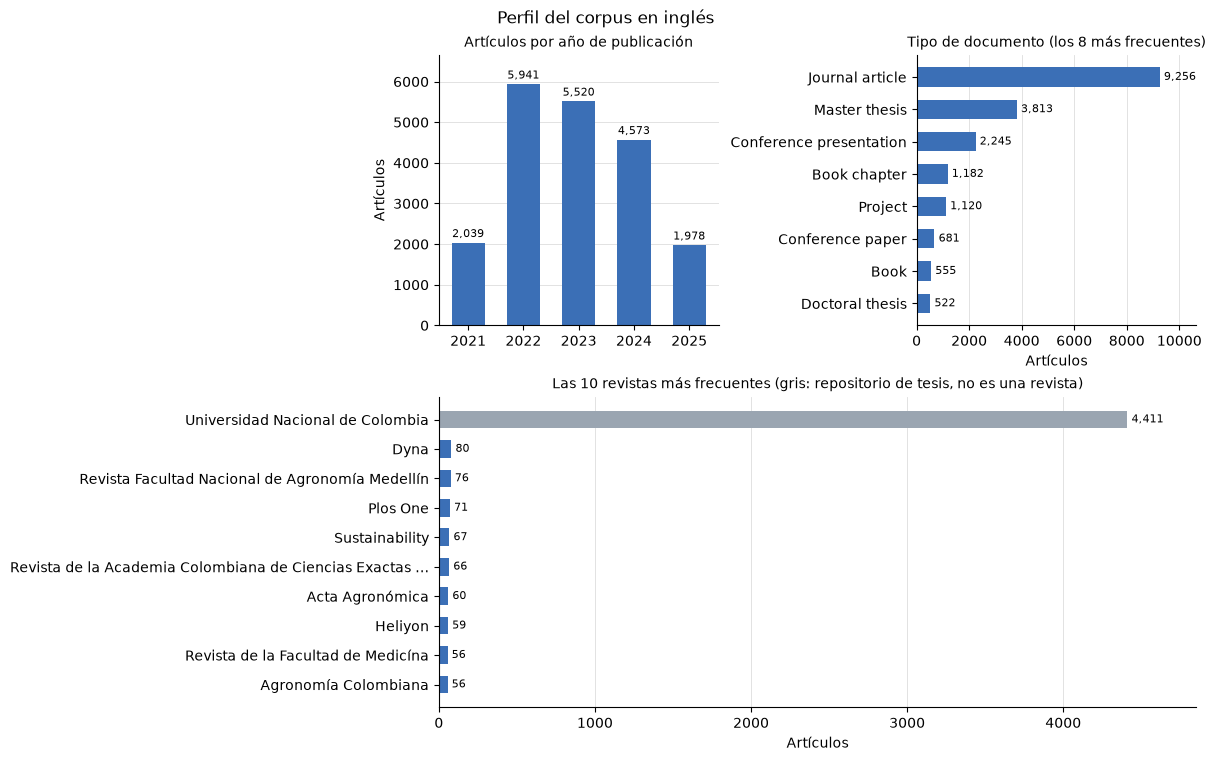

Artículos con revista: 16,143 de 20,051 (80.5%) | revistas distintas: 4,945


In [16]:
import matplotlib.pyplot as plt

PLOT_COLOR = '#3b6fb6'
PLOT_MUTED = '#9aa5b1'                                  # contexto o categorías que no son el foco
REPOSITORY_JOURNAL = 'Universidad Nacional de Colombia'  # en el Excel figura como "revista" de las tesis del repositorio
PROFILE_TOP_JOURNALS = 10
JOURNAL_LABEL_CHARS = 55


def style_axes(ax, grid_axis='y'):
    """Ejes discretos: sin marco superior ni derecho y cuadrícula tenue."""
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis=grid_axis, color='#dddddd', linewidth=0.6)
    ax.set_axisbelow(True)


def label_bars(ax, bars, fmt='{:,.0f}', horizontal=False):
    """Escribe el valor de cada barra junto a ella."""
    for bar in bars:
        value = bar.get_width() if horizontal else bar.get_height()
        x, y = (value, bar.get_y() + bar.get_height() / 2) if horizontal else (bar.get_x() + bar.get_width() / 2, value)
        ax.annotate(fmt.format(value), (x, y), xytext=(3, 0) if horizontal else (0, 2), textcoords='offset points',
                    ha='left' if horizontal else 'center', va='center' if horizontal else 'bottom', fontsize=8)


fig = plt.figure(figsize=(12, 7.5), layout='constrained')
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.15])

ax = fig.add_subplot(grid[0, 0])
per_year = papers['publication_year'].dropna().astype(int).value_counts().sort_index()
label_bars(ax, ax.bar(per_year.index.astype(str), per_year.values, color=PLOT_COLOR, width=0.6))
ax.set_title('Artículos por año de publicación', fontsize=10)
ax.set_ylabel('Artículos')
ax.margins(y=0.12)
style_axes(ax)

ax = fig.add_subplot(grid[0, 1])
per_type = papers['document_type_normalized'].str.replace('_', ' ').str.capitalize().value_counts().head(8)[::-1]
label_bars(ax, ax.barh(per_type.index, per_type.values, color=PLOT_COLOR, height=0.6), horizontal=True)
ax.set_title('Tipo de documento (los 8 más frecuentes)', fontsize=10)
ax.set_xlabel('Artículos')
ax.margins(x=0.15)
style_axes(ax, grid_axis='x')

ax = fig.add_subplot(grid[1, :])
journals = papers['journal_normalized'].replace('', np.nan).dropna()
top_journals = journals.value_counts().head(PROFILE_TOP_JOURNALS)[::-1]
colors = [PLOT_MUTED if name == REPOSITORY_JOURNAL else PLOT_COLOR for name in top_journals.index]
names = [name if len(name) <= JOURNAL_LABEL_CHARS else name[:JOURNAL_LABEL_CHARS - 1] + '…' for name in top_journals.index]
label_bars(ax, ax.barh(names, top_journals.values, color=colors, height=0.6), horizontal=True)
ax.set_title(f'Las {PROFILE_TOP_JOURNALS} revistas más frecuentes (gris: repositorio de tesis, no es una revista)', fontsize=10)
ax.set_xlabel('Artículos')
ax.margins(x=0.1)
style_axes(ax, grid_axis='x')

fig.suptitle('Perfil del corpus en inglés', fontsize=12)
plt.show()
print(f'Artículos con revista: {len(journals):,} de {len(papers):,} ({len(journals) / len(papers):.1%}) | revistas distintas: {journals.nunique():,}')

**Interpretación:** el corpus cubre solo **2021-2025**, con un máximo en 2022, y casi la mitad son artículos de revista; las tesis de maestría, las ponencias y los capítulos de libro forman el resto. Los tipos de documento son muy distintos entre sí (longitud, estilo, vocabulario), lo que ayuda a entender por qué las similitudes son bajas en términos absolutos. La "revista" más frecuente, `Universidad Nacional de Colombia`, no es una revista sino el repositorio donde figuran las tesis, así que dos tesis del repositorio "comparten revista" sin que eso indique afinidad temática; hay que tenerlo en cuenta al describir los grupos de artículos más adelante.

### Vectorización

In [17]:
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer

TFIDF_NGRAM_RANGE = (1, 1)   # los bigramas no mejoran y multiplican el vocabulario por 6 (ver comparación más abajo)
TFIDF_MIN_DF = 3          # descarta términos de 1-2 artículos (erratas, nombres propios sueltos)
TFIDF_MAX_DF = 0.8        # descarta plantilla que se haya colado en DOMAIN_STOPWORDS
TFIDF_SUBLINEAR_TF = True
TFIDF_MATRIX_FILE = Path(OUTPUT_DIR) / 'tfidf_matrix.npz'
TFIDF_IDS_FILE = Path(OUTPUT_DIR) / 'tfidf_paper_ids.csv'


def build_tfidf(texts, ngram_range=TFIDF_NGRAM_RANGE, min_df=TFIDF_MIN_DF, max_df=TFIDF_MAX_DF):
    """Ajusta TF-IDF sobre textos ya tokenizados (tokens separados por espacio)."""
    vectorizer = TfidfVectorizer(tokenizer=str.split, preprocessor=None, lowercase=False, token_pattern=None,
                                 ngram_range=ngram_range, min_df=min_df, max_df=max_df,
                                 sublinear_tf=TFIDF_SUBLINEAR_TF, norm='l2', dtype=np.float32)
    return vectorizer, vectorizer.fit_transform(texts)


# Solo artículos con tokens; un texto vacío no tiene vector con el que comparar.
has_tokens = papers['text_tokens'].str.len() > 0
tfidf_papers = papers.loc[has_tokens].reset_index(drop=True)
print(f'Artículos sin tokens (excluidos): {(~has_tokens).sum():,}')

tfidf_vectorizer, tfidf_matrix = build_tfidf(tfidf_papers['text_tokens'])

# Un artículo cuyos términos quedaron todos fuera por min_df/max_df tiene vector nulo: se excluye y se reajusta.
nonzero_rows = tfidf_matrix.getnnz(axis=1) > 0
if not nonzero_rows.all():
    print(f'Artículos con vector nulo tras min_df/max_df (excluidos): {(~nonzero_rows).sum():,}')
    tfidf_papers = tfidf_papers.loc[nonzero_rows].reset_index(drop=True)
    tfidf_vectorizer, tfidf_matrix = build_tfidf(tfidf_papers['text_tokens'])

tfidf_ids = tfidf_papers['paper_id'].to_numpy()
tfidf_vocabulary = tfidf_vectorizer.get_feature_names_out()

sparse.save_npz(TFIDF_MATRIX_FILE, tfidf_matrix)
pd.DataFrame({'paper_id': tfidf_ids}).to_csv(TFIDF_IDS_FILE, index=False)

n_docs, n_terms = tfidf_matrix.shape
n_bigrams = sum(' ' in term for term in tfidf_vocabulary)
summary = pd.Series({
    'Documentos': f'{n_docs:,}',
    'Términos en el vocabulario': f'{n_terms:,}',
    'De ellos, bigramas': f'{n_bigrams:,} ({n_bigrams / n_terms:.1%})',
    'Densidad de la matriz': f'{tfidf_matrix.nnz / (n_docs * n_terms):.4%}',
    'Mediana de términos por documento': int(np.median(tfidf_matrix.getnnz(axis=1))),
}, name='valor')
display(summary.to_frame())
print(f'Guardado: {TFIDF_MATRIX_FILE}')

Artículos sin tokens (excluidos): 0


,valor
Documentos,"20,051"
Términos en el vocabulario,"25,071"
"De ellos, bigramas",0 (0.0%)
Densidad de la matriz,0.2841%
Mediana de términos por documento,70


Guardado: output/tfidf_matrix.npz


#### Términos con más y menos peso

Dos rankings independientes. El primero muestra los términos con mayor **peso TF-IDF medio** en el corpus; el segundo, los de **menor IDF** que sobrevivieron al filtro, es decir, los más comunes. La columna `fracción de artículos` indica en qué parte del corpus aparece cada término y explica por qué los genéricos encabezan la primera lista: el peso medio favorece a los términos que aparecen en muchos artículos, no necesariamente a los que mejor los caracterizan. Si aparece vocabulario de plantilla académica, conviene añadirlo a `DOMAIN_STOPWORDS` y volver a tokenizar.

In [18]:
N_TOP_TERMS = 20

mean_weight = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
doc_share = tfidf_matrix.getnnz(axis=0) / tfidf_matrix.shape[0]      # fracción de artículos que contiene cada término
top_weight = np.argsort(-mean_weight)[:N_TOP_TERMS]
lowest_idf = np.argsort(tfidf_vectorizer.idf_)[:N_TOP_TERMS]

print('Mayor peso TF-IDF medio:')
display(pd.DataFrame({'término': tfidf_vocabulary[top_weight],
                      'peso medio': mean_weight[top_weight].round(4),
                      'fracción de artículos': doc_share[top_weight].round(3)}))
print('Menor IDF (los más comunes):')
display(pd.DataFrame({'término': tfidf_vocabulary[lowest_idf],
                      'IDF': tfidf_vectorizer.idf_[lowest_idf].round(2),
                      'fracción de artículos': doc_share[lowest_idf].round(3)}))

Mayor peso TF-IDF medio:


,término,peso medio,fracción de artículos
0,analysis,0.0164,0.324
1,model,0.0163,0.233
2,process,0.0152,0.259
3,research,0.0144,0.259
4,system,0.0140,0.207
5,high,0.0139,0.278
6,development,0.0116,0.192
7,data,0.0115,0.181
8,effect,0.0107,0.175
9,method,0.0107,0.168


Menor IDF (los más comunes):


,término,IDF,fracción de artículos
0,analysis,2.13,0.324
1,high,2.28,0.278
2,research,2.35,0.259
3,process,2.35,0.259
4,model,2.46,0.233
5,system,2.57,0.207
6,evaluate,2.58,0.206
7,identify,2.64,0.194
8,development,2.65,0.192
9,data,2.71,0.181


**Interpretación:** el vocabulario dominante es genérico (`analysis`, `model`, `process`, `research`, `system`, `high`, `development`), sin ser plantilla de una editorial. `colombia` y `colombian` aparecían entre los primeros (todo el corpus es de la UNAL) y se añadieron a `DOMAIN_STOPWORDS`. No se añaden más palabras frecuentes a esa lista: el peso IDF ya resta importancia a estos términos.

### Vecinos más similares

La matriz completa de similitudes (N × N) ocuparía unos 1,6 GB para este corpus; para no depender de la memoria disponible en Colab se calcula **por bloques de filas**. Como las filas están normalizadas (L2), el coseno es un simple producto punto, y de cada fila solo se guardan los `TOP_K` mejores. El resultado es idéntico al de la matriz completa: es una precaución de memoria, no una aproximación. Se excluye el propio artículo y se descartan los pares por debajo de `MIN_SIMILARITY`.

In [19]:
TOP_K = 10
MIN_SIMILARITY = 0.10     # por debajo, la conexión es demasiado débil para usarla como arista
SIMILARITY_BATCH_SIZE = 1000


def top_k_neighbors(matrix, paper_ids, k=TOP_K, min_similarity=MIN_SIMILARITY, batch_size=SIMILARITY_BATCH_SIZE):
    """Top-k vecinos por coseno de cada fila; `matrix` debe tener filas normalizadas L2."""
    n = matrix.shape[0]
    k = min(k, n - 1)
    frames = []
    for start in range(0, n, batch_size):
        stop = min(start + batch_size, n)
        scores = matrix[start:stop] @ matrix.T
        scores = scores.toarray() if sparse.issparse(scores) else np.asarray(scores)
        rows = np.arange(stop - start)
        scores[rows, np.arange(start, stop)] = -np.inf          # excluir el propio artículo
        top = np.argpartition(-scores, k - 1, axis=1)[:, :k]
        top_scores = scores[rows[:, None], top]
        order = np.argsort(-top_scores, axis=1)
        top, top_scores = top[rows[:, None], order], top_scores[rows[:, None], order]
        frames.append(pd.DataFrame({
            'source_idx': np.repeat(np.arange(start, stop), k),
            'target_idx': top.ravel(),
            'similarity_score': top_scores.ravel(),
            'rank': np.tile(np.arange(1, k + 1), stop - start),
        }))
    pairs = pd.concat(frames, ignore_index=True)
    pairs = pairs.loc[pairs['similarity_score'] >= min_similarity].reset_index(drop=True)
    pairs.insert(0, 'paper_id_1', paper_ids[pairs['source_idx']])
    pairs.insert(1, 'paper_id_2', paper_ids[pairs['target_idx']])
    return pairs


_t0 = time.time()
tfidf_pairs = top_k_neighbors(tfidf_matrix, tfidf_ids)
print(f'Vecinos calculados en {time.time() - _t0:,.0f} s')
print(f'Pares (artículo, vecino): {len(tfidf_pairs):,} | '
      f'artículos con al menos un vecino: {tfidf_pairs["source_idx"].nunique():,} de {n_docs:,}')

Vecinos calculados en 17 s
Pares (artículo, vecino): 200,041 | artículos con al menos un vecino: 20,051 de 20,051


### Términos compartidos y tabla de similitudes

Para poder explicar cada conexión se guardan los `N_SHARED_TERMS` términos que más aportan al coseno de cada par (producto elemento a elemento de los dos vectores). El resultado es `similarities`, que usa la celda de exportación (`output/similarity_candidates.csv`).

In [20]:
N_SHARED_TERMS = 5
TFIDF_SIMILARITIES_FILE = Path(OUTPUT_DIR) / 'tfidf_similarities.csv'


def add_shared_terms(pairs, matrix, vocabulary, n_terms=N_SHARED_TERMS):
    """Añade los términos que más aportan al coseno de cada par (producto elemento a elemento)."""
    shared = pd.Series('', index=pairs.index, dtype=object)
    for source_idx, group in pairs.groupby('source_idx'):
        # una sola multiplicación por artículo para todos sus vecinos
        contribution = matrix[group['target_idx'].to_numpy()].multiply(matrix[source_idx]).tocsr()
        terms = []
        for pos in range(len(group)):
            start, end = contribution.indptr[pos], contribution.indptr[pos + 1]
            cols, values = contribution.indices[start:end], contribution.data[start:end]
            best = cols[np.argsort(-values)[:n_terms]]
            terms.append(', '.join(vocabulary[best]))
        shared.loc[group.index] = terms
    return pairs.assign(shared_terms=shared)


tfidf_pairs = add_shared_terms(tfidf_pairs, tfidf_matrix, tfidf_vocabulary)

similarities = tfidf_pairs[['paper_id_1', 'paper_id_2', 'similarity_score', 'rank', 'shared_terms']].copy()
similarities['similarity_score'] = similarities['similarity_score'].round(4)
similarities.insert(4, 'method', 'tfidf')
similarities.to_csv(TFIDF_SIMILARITIES_FILE, index=False, encoding='utf-8-sig')
print(f'Guardado: {TFIDF_SIMILARITIES_FILE} ({len(similarities):,} pares)')

tfidf_titles = tfidf_papers.set_index('paper_id')[TITLE_COLUMN]


def show_neighbors(paper_id, pairs, n=5):
    """Muestra el artículo y sus n vecinos más similares con los términos compartidos."""
    neighbors = pairs.loc[pairs['paper_id_1'] == paper_id].nsmallest(n, 'rank')
    print(f'{paper_id}: {tfidf_titles[paper_id]}')
    display(pd.DataFrame({
        'rank': neighbors['rank'].values,
        'similitud': neighbors['similarity_score'].round(3).values,
        'vecino': neighbors['paper_id_2'].map(tfidf_titles).values,
        'términos compartidos': neighbors['shared_terms'].values,
    }))


show_neighbors(tfidf_ids[0], tfidf_pairs)

Guardado: output/tfidf_similarities.csv (200,041 pares)
HORUS_000004: Recent advances in solvent development for carbon capture


,rank,similitud,vecino,términos compartidos
0,1,0.216,"SELF DIFFUSION, VISCOSITY, AND SURFACE TENSION...","amine, viscosity, diffusivity, absorption, pro..."
1,2,0.181,Solubility study of mesalazine in the aqueous ...,"solvent, eutectic, thermodynamic, property, deep"
2,3,0.180,"CO2 CAPTURE METHODS, GREEN EFFECT GAS WITH GRE...","capture, carbon, absorption, emission, heat"
3,4,0.176,Solubility study of lamotrigine in the aqueous...,"solvent, eutectic, thermodynamic, property, deep"
4,5,0.174,Molecular Dynamic Simulation of the Interactio...,"solvent, eutectic, carbon, aqueous, deep"


#### Distribución de las puntuaciones

A la izquierda, la similitud del **vecino más cercano** de cada artículo; a la derecha, la de **todos** los vecinos guardados. Una cola larga hacia 1 indica artículos casi idénticos.

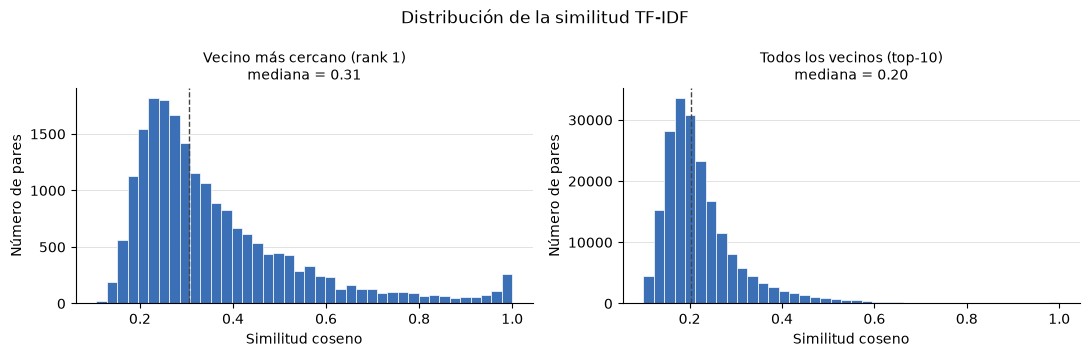

In [21]:
import matplotlib.pyplot as plt

PLOT_COLOR = '#3b6fb6'
BINS = 40

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
panels = [
    (tfidf_pairs.loc[tfidf_pairs['rank'] == 1, 'similarity_score'], 'Vecino más cercano (rank 1)'),
    (tfidf_pairs['similarity_score'], f'Todos los vecinos (top-{TOP_K})'),
]
for ax, (scores, title) in zip(axes, panels):
    ax.hist(scores, bins=BINS, color=PLOT_COLOR, edgecolor='white', linewidth=0.5)
    ax.axvline(scores.median(), color='#444444', linewidth=1, linestyle='--')
    ax.set_title(f'{title}\nmediana = {scores.median():.2f}', fontsize=10)
    ax.set_xlabel('Similitud coseno')
    ax.set_ylabel('Número de pares')
    ax.grid(axis='y', color='#dddddd', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Distribución de la similitud TF-IDF', fontsize=12)
fig.tight_layout()
plt.show()

#### Posibles duplicados restantes

Tras la deduplicación por DOI o título de la sección de limpieza, los pares con similitud muy alta que quedan son casos que ese criterio no capta: el mismo título con otro año o DOI, o el mismo abstract con el título distinto o traducido. Por eso conviene revisarlos.

In [22]:
NEAR_DUPLICATE_THRESHOLD = 0.9

near = tfidf_pairs.loc[tfidf_pairs['similarity_score'] >= NEAR_DUPLICATE_THRESHOLD].copy()
# (A, B) y (B, A) son el mismo par: se deja uno solo.
near['pair_key'] = [tuple(sorted(p)) for p in zip(near['source_idx'], near['target_idx'])]
near = near.drop_duplicates('pair_key').sort_values('similarity_score', ascending=False)

print(f'Pares con similitud >= {NEAR_DUPLICATE_THRESHOLD}: {len(near):,}')
display(pd.DataFrame({
    'similitud': near['similarity_score'].round(3).head(10).values,
    'título 1': near['paper_id_1'].map(tfidf_titles).head(10).values,
    'título 2': near['paper_id_2'].map(tfidf_titles).head(10).values,
}))

Pares con similitud >= 0.9: 290


,similitud,título 1,título 2
0,1.0,VALUATION OF ORGANOCATALIZED GLYCEROL BY N-HET...,VALUATION OF ORGANOCATALIZED GLYCEROL BY N-HET...
1,1.0,RISK FACTORS AND LIFESTYLES IN ADOLESCENTS ASS...,Risk factors and lifestyles in adolescents ass...
2,1.0,Oceanic intraplate faulting as a pathway for d...,OCEANIC INTRAPLATE FAULTING AS A PATHWAY FOR D...
3,1.0,Use of computer vision to analyze cyclic loads...,USE OF COMPUTER VISION TO ANALYZE CYCLIC LOADS...
4,1.0,ADVANCES IN QUANTUM DOT APPLICATIONS FOR THE O...,Advances in Quantum Dot Applications for the O...
5,1.0,DIAGNOSTIC ACCURACY OF SCREENING TESTS FOR DIA...,Diagnostic Accuracy of Screening Tests for Dia...
6,1.0,ANALYSIS OF CALCIUM CITRATE SALTS AS RAW MATER...,Analysis of Calcium Citrate Salts as Raw Mater...
7,1.0,Parents’ literacy on mobile advertising aimed ...,PARENTS¿ LITERACY ON MOBILE ADVERTISING AIMED ...
8,1.0,Methodology for Electrochemical Impedance Spec...,METHODOLOGY FOR ELECTROCHEMICAL IMPEDANCE SPEC...
9,1.0,The Prevalence and Genetic Diversity of PCV3 a...,The prevalence and genetic diversity of PCV3 a...


**Interpretación:** con la deduplicación aplicada quedan unos 290 pares con similitud ≥ 0,9 (frente a más de 640, con 1.200 artículos implicados, antes de deduplicar). Son de dos tipos: unos 90 con el **mismo título** pero distinto año o distinto DOI (el criterio los deja porque podrían ser trabajos distintos, como una versión de congreso y otra de revista) y unos 200 con **títulos distintos y abstract casi idéntico** (versión traducida, variantes del título, capítulos que repiten el resumen). Conviene revisarlos a mano: un criterio automático más agresivo eliminaría también artículos distintos con títulos genéricos.

#### Ejemplos cualitativos

Tres artículos fijos de temas distintos, con sus vecinos más cercanos y los términos que explican la conexión. Sirve para revisar a ojo si los vecinos tienen sentido; los mismos artículos se usan en la sección de Doc2Vec.

In [23]:
# Fijos por paper_id para ver los mismos artículos con TF-IDF y con Doc2Vec.
EXAMPLE_PAPER_IDS = [
    'HORUS_000123',   # revisión sobre analítica en salud y machine learning
    'HORUS_000037',   # compuestos antimicrobianos contra bacterias fitopatógenas
    'HORUS_000010',   # clínicas de transición en reumatología pediátrica
]
N_EXAMPLE_NEIGHBORS = 5

for paper_id in EXAMPLE_PAPER_IDS:
    if paper_id not in tfidf_titles.index:
        print(f'\n{paper_id}: no está en el corpus (¿cambió el dataset o los filtros?)')
        continue
    print()
    show_neighbors(paper_id, tfidf_pairs, n=N_EXAMPLE_NEIGHBORS)


HORUS_000123: Advancing healthcare analytics: a thematic review of machine learning, health informatics, and real-world data applications


,rank,similitud,vecino,términos compartidos
0,1,0.269,"An analysis of trends, challenges, and opportu...","analytic, digital, data, challenge, drive"
1,2,0.256,Emerging trends and strategic opportunities in...,"thematic, ai, learning, privacy, theme"
2,3,0.235,DATA GENERATION STRATEGIES FOR THE IMPLEMENTAT...,"analytic, adaptive, learning, data, learn"
3,4,0.229,Trends in Business Analytics Education: Innova...,"analytic, theme, learning, ethical, innovation"
4,5,0.225,MENTAL HEALTH IN ORGANIZATIONS FROM A HEALTHCA...,"analytic, healthcare, mental, health, trend"



HORUS_000037: Isolation and identification of antimicrobial compounds produced by Bacillus nakamurai CBAS-959 and their activity against phytopathogenic bacteria


,rank,similitud,vecino,términos compartidos
0,1,0.213,OPTIMIZATION OF AGNPS PRODUCTION FROM FUSARIUM...,"carotovorum, phytopathogenic, pectobacterium, ..."
1,2,0.210,Evaluation of bioactive bacterial extracts aga...,"carotovorum, bacillus, bacteria, extract, purify"
2,3,0.203,"Synthesis, characterization and evaluation of ...","solanacearum, phytopathogenic, ralstonia, phyt..."
3,4,0.202,Assessment of microbial antagonistic activity ...,"phytopathogenic, bacillus, phytopathogen, bact..."
4,5,0.179,Antimicrobial Activity of Ethanolic Propolis E...,"antimicrobial, mic, assay, culture, co"



HORUS_000010: Transition clinics in pediatric rheumatology in Colombia: reflection on a necessary shortcomings


,rank,similitud,vecino,términos compartidos
0,1,0.231,TRANSITION OF ADOLECENT TO MEDICAL ADULTS SERV...,"transition, pediatric, medical, patient, family"
1,2,0.188,2024 SIAC guidelines on cardiorespiratory reha...,"pediatric, guideline, patient, disease, care"
2,3,0.174,pedagogical Strategy for teaching infection in...,"pediatric, medical, dedicate, educational, mor..."
3,4,0.172,Design and implementation of clinical care cen...,"patient, team, care, chronic, disease"
4,5,0.172,Evidence-based clinical standard: Diagnosis an...,"clinic, patient, disease, evidence, care"


**Interpretación:** los vecinos son más coherentes cuanto más específico es el vocabulario del artículo:

- **Compuestos antimicrobianos contra fitopatógenos (`HORUS_000037`):** los 5 vecinos tratan de actividad antimicrobiana o antagonista contra bacterias de plantas, y los términos compartidos son nombres de especies y del método (`carotovorum`, `pectobacterium`, `solanacearum`, `bacillus`, `mic`). Es el caso más claro de lo que TF-IDF hace bien: conectar por vocabulario técnico raro.
- **Clínicas de transición en reumatología pediátrica (`HORUS_000010`):** el vecino más cercano trata justo del mismo tema, la transición de adolescentes a servicios de adultos, gracias a `transition` y `pediatric`. Los demás son guías y centros de atención clínica unidos por palabras más generales (`patient`, `care`, `disease`).
- **Revisión sobre analítica en salud (`HORUS_000123`):** los vecinos son otras revisiones de tendencias en analítica e inteligencia artificial (negocios, estrategia, salud mental en organizaciones), unidos por `analytic`, `thematic`, `trend`. El tipo de texto (revisión temática) pesa tanto como el dominio.

Las similitudes son bajas (≈0,17-0,27): los vecinos más débiles comparten sobre todo palabras genéricas y son los menos fiables.

#### Vecindad de un artículo como grafo

Vista de las conexiones que saldrán de TF-IDF hacia el grafo de conocimiento: un artículo en el centro y sus vecinos más cercanos alrededor. La **longitud de cada línea es la distancia coseno** (1 − similitud), así que cuanto más parecido es un vecino, más cerca del centro queda; los círculos grises marcan valores de similitud como referencia (el más externo es similitud 0). El **grosor** de la línea también es proporcional a la similitud y, junto a cada vecino, aparecen los términos que explican la conexión.

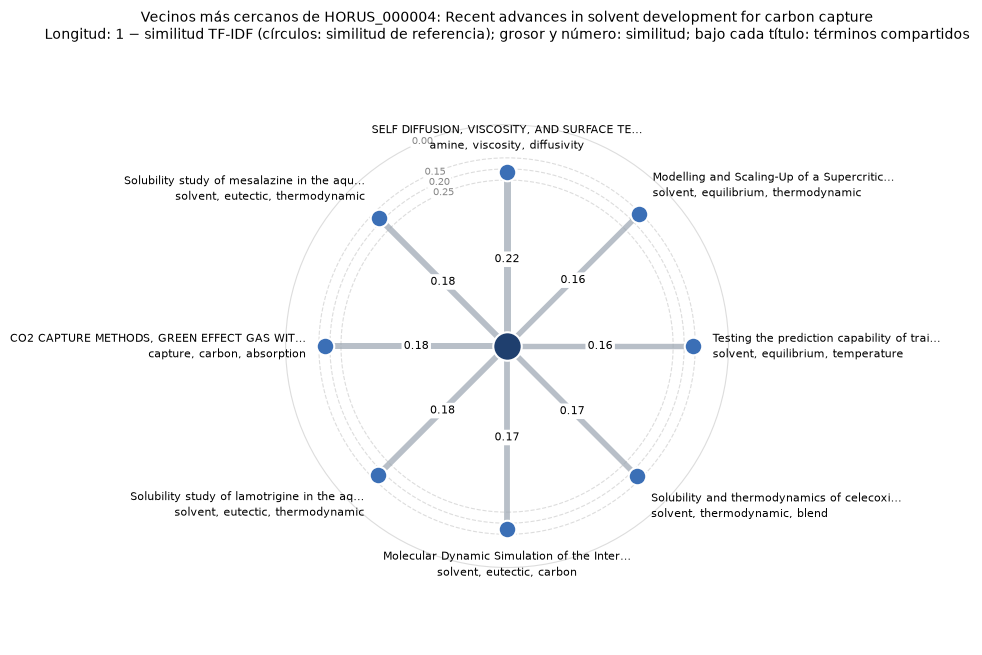

In [24]:
GRAPH_PAPER_ID = tfidf_ids[0]
GRAPH_NEIGHBORS = 8
GRAPH_TITLE_CHARS = 42
GRAPH_TERMS_SHOWN = 3
GRAPH_RING_STEP = 0.05    # separación entre los círculos de referencia de similitud


def short(text, chars):
    """Recorta un título largo para que quepa en la figura."""
    return text if len(text) <= chars else text[:chars - 1] + '…'


ego = tfidf_pairs.loc[tfidf_pairs['paper_id_1'] == GRAPH_PAPER_ID].nsmallest(GRAPH_NEIGHBORS, 'rank')
scores = ego['similarity_score'].to_numpy()
angles = np.linspace(0, 2 * np.pi, len(ego), endpoint=False) + np.pi / 2
radii = 1 - scores                                   # distancia coseno: más similar, más cerca del centro
xs, ys = radii * np.cos(angles), radii * np.sin(angles)
widths = 0.8 + 4.2 * scores / scores.max()

fig, ax = plt.subplots(figsize=(12, 9))

# Círculos de referencia: similitud 0 (borde exterior) y valores redondos alrededor de los vecinos.
ring_scores = np.arange(np.floor(scores.min() / GRAPH_RING_STEP) * GRAPH_RING_STEP,
                        scores.max() + GRAPH_RING_STEP, GRAPH_RING_STEP)
ring_angle = angles[0] + np.pi / len(ego)          # entre los dos primeros vecinos, para no tapar ninguno
for ring in np.unique(np.round(np.r_[0.0, ring_scores], 2)):
    ax.add_patch(plt.Circle((0, 0), 1 - ring, fill=False, color='#dddddd', linewidth=0.8,
                            linestyle='-' if ring == 0 else '--', zorder=0))
    ax.annotate(f'{ring:.2f}', ((1 - ring) * np.cos(ring_angle), (1 - ring) * np.sin(ring_angle)), ha='center',
                va='center', fontsize=7, color='#888888', bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none'),
                zorder=0)

for x, y, width, score in zip(xs, ys, widths, scores):
    ax.plot([0, x], [0, y], color=PLOT_MUTED, linewidth=width, alpha=0.7, solid_capstyle='round', zorder=1)
    ax.annotate(f'{score:.2f}', (x * 0.5, y * 0.5), ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none'), zorder=3)
ax.scatter(xs, ys, s=160, color=PLOT_COLOR, edgecolor='white', linewidth=1.5, zorder=2)
ax.scatter([0], [0], s=420, color='#1f3f6e', edgecolor='white', linewidth=1.5, zorder=2)

# Cada título se escribe hacia afuera, en la dirección de su línea.
for angle, x, y, (_, row) in zip(angles, xs, ys, ego.iterrows()):
    terms = ', '.join(row['shared_terms'].split(', ')[:GRAPH_TERMS_SHOWN])
    dx, dy = np.cos(angle), np.sin(angle)
    ha = 'left' if dx > 0.2 else 'right' if dx < -0.2 else 'center'
    ax.annotate(f'{short(tfidf_titles[row["paper_id_2"]], GRAPH_TITLE_CHARS)}\n{terms}', (x, y),
                xytext=(14 * dx, 14 * dy), textcoords='offset points', ha=ha,
                va='bottom' if dy > 0.5 else 'top' if dy < -0.5 else 'center', fontsize=8, linespacing=1.4)

ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-1.35, 1.35)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Vecinos más cercanos de {GRAPH_PAPER_ID}: {short(tfidf_titles[GRAPH_PAPER_ID], 80)}\n'
             'Longitud: 1 − similitud TF-IDF (círculos: similitud de referencia); grosor y número: similitud; '
             'bajo cada título: términos compartidos', fontsize=10)
plt.show()

**Interpretación:** cada línea es una arista candidata del grafo, con su peso (la similitud) y su explicación (los términos compartidos). Con la longitud a escala se ve que todos los vecinos quedan cerca del borde (similitud 0): con TF-IDF las similitudes son bajas en valor absoluto, y lo que distingue a un vecino de otro son diferencias de pocas centésimas. Los vecinos más cercanos comparten vocabulario técnico del tema, y las conexiones más débiles se apoyan en palabras más generales. Esta es la estructura que se reutilizará con los otros métodos de similitud.

#### Sensibilidad a los parámetros

Se compara la configuración elegida con otras combinaciones de `ngram_range` y `min_df`. Como no hay etiquetas, no se mide cuál es mejor sino **cuánto cambian los vecinos**: la fracción de los `TOP_K` vecinos de cada artículo que coincide con los de la configuración elegida, junto con el tamaño del vocabulario y el tiempo. Los artículos se mantienen alineados con `tfidf_papers`: si una configuración deja a un artículo sin términos, simplemente no tiene vecinos.

In [25]:
RUN_SENSITIVITY = True
SENSITIVITY_NGRAMS = [(1, 1), (1, 2)]
SENSITIVITY_MIN_DF = [2, 3, 5]


def neighbor_overlap(pairs, reference):
    """Fracción media de los vecinos de `reference` que también aparecen en `pairs`, por artículo."""
    ours = pairs.groupby('source_idx')['target_idx'].agg(set)
    theirs = reference.groupby('source_idx')['target_idx'].agg(set)
    common = theirs.index.intersection(ours.index)
    return np.mean([len(ours[i] & theirs[i]) / len(theirs[i]) for i in common])


if RUN_SENSITIVITY:
    rows = []
    for ngram_range in SENSITIVITY_NGRAMS:
        for min_df in SENSITIVITY_MIN_DF:
            _t0 = time.time()
            _, matrix = build_tfidf(tfidf_papers['text_tokens'], ngram_range=ngram_range, min_df=min_df)
            pairs = top_k_neighbors(matrix, tfidf_ids)
            rows.append({
                'ngram_range': str(ngram_range),
                'min_df': min_df,
                'vocabulario': matrix.shape[1],
                'vecinos en común con la elegida': neighbor_overlap(pairs, tfidf_pairs),
                'similitud media rank 1': pairs.loc[pairs['rank'] == 1, 'similarity_score'].mean(),
                'segundos': time.time() - _t0,
            })
    sensitivity = pd.DataFrame(rows)
    display(sensitivity.style.format({
        'vocabulario': '{:,}', 'vecinos en común con la elegida': '{:.1%}',
        'similitud media rank 1': '{:.3f}', 'segundos': '{:.0f}',
    }).hide(axis='index'))

ngram_range,min_df,vocabulario,vecinos en común con la elegida,similitud media rank 1,segundos
"(1, 1)",2,"36,086",93.7%,0.355,20
"(1, 1)",3,"25,071",100.0%,0.361,20
"(1, 1)",5,"16,936",92.1%,0.366,21
"(1, 2)",2,"296,501",49.2%,0.263,23
"(1, 2)",3,"144,010",60.7%,0.279,22
"(1, 2)",5,"64,989",67.1%,0.304,22


**Interpretación:** `min_df` apenas cambia los vecinos: con 2 o 5 se conservan ≈92-94 % de los vecinos de la configuración elegida, aunque el vocabulario pasa de ≈17.000 a ≈36.000 términos. Los bigramas cambian mucho más (solo ≈49-67 % de vecinos en común), multiplican el vocabulario (de ≈65.000 a ≈297.000 términos) y bajan la similitud del vecino más cercano (≈0,26-0,30 frente a ≈0,36), porque el peso de cada artículo se reparte entre muchos más términos. Sin etiquetas no se puede decir cuáles vecinos son mejores, así que se elige la opción más simple y barata: **unigramas con `min_df=3`**.

#### Unigramas frente a bigramas

Para justificar la elección se comparan las dos representaciones con el mismo `min_df`: el tamaño del vocabulario y **cuánto coinciden los vecinos** que producen. Si los bigramas trajeran vecinos muy distintos, valdría la pena revisarlos a mano; si solo los reordenan, no justifican un vocabulario mucho mayor.

In [26]:
COMPARE_NGRAMS = {'unigramas': (1, 1), 'unigramas + bigramas': (1, 2)}

compared = {}
for name, ngram_range in COMPARE_NGRAMS.items():
    _, matrix = build_tfidf(tfidf_papers['text_tokens'], ngram_range=ngram_range, min_df=TFIDF_MIN_DF)
    pairs = top_k_neighbors(matrix, tfidf_ids)
    compared[name] = {'vocabulario': matrix.shape[1], 'pairs': pairs,
                      'similitud_media_rank1': pairs.loc[pairs['rank'] == 1, 'similarity_score'].mean()}

display(pd.DataFrame({
    name: {
        'términos en el vocabulario': f'{r["vocabulario"]:,}',
        'similitud media del rank 1': f'{r["similitud_media_rank1"]:.3f}',
    } for name, r in compared.items()
}))

# Coincidencia entre los vecinos de las dos representaciones.
uni, bi = (compared[name]['pairs'] for name in COMPARE_NGRAMS)
neighbors_bi = bi.groupby('source_idx')['target_idx'].agg(set)
first_uni = uni.loc[uni['rank'] == 1].set_index('source_idx')['target_idx']
first_bi = bi.loc[bi['rank'] == 1].set_index('source_idx')['target_idx']
shared_sources = first_uni.index.intersection(first_bi.index)
same_first = (first_uni[shared_sources] == first_bi[shared_sources]).mean()
first_in_other = np.mean([first_uni[i] in neighbors_bi[i] for i in shared_sources])

print(f'Vecinos en común (de los {TOP_K}, en promedio): {neighbor_overlap(bi, uni):.1%}')
print(f'Mismo vecino más cercano: {same_first:.1%}')
print(f'El vecino más cercano de unigramas aparece entre los {TOP_K} de bigramas: {first_in_other:.1%}')

,unigramas,unigramas + bigramas
términos en el vocabulario,"25,071","144,010"
similitud media del rank 1,0.361,0.279


Vecinos en común (de los 10, en promedio): 60.7%
Mismo vecino más cercano: 65.8%
El vecino más cercano de unigramas aparece entre los 10 de bigramas: 94.6%


**Interpretación:** con el mismo `min_df`, los bigramas multiplican el vocabulario por ≈6 (25.071 frente a 144.010 términos). Los vecinos no son idénticos: comparten ≈61 % de los 10 y el vecino más cercano coincide en ≈66 % de los casos. Pero el vecino más cercano con unigramas aparece casi siempre (≈95 %) entre los 10 de bigramas: los bigramas **reordenan** a los vecinos más que traer otros distintos. Como no hay forma de medir cuál orden es mejor, no justifican un vocabulario 6 veces mayor y se usan unigramas.

#### Similitud por tipo de documento y artículos "populares"

Dos comprobaciones sobre cómo se reparten las conexiones. A la izquierda, cuánto se parece el vecino más cercano según el tipo de documento (solo tipos con suficientes artículos). A la derecha, cuántas veces aparece cada artículo como vecino de otro: si unos pocos aparecen demasiado, dominan las conexiones.

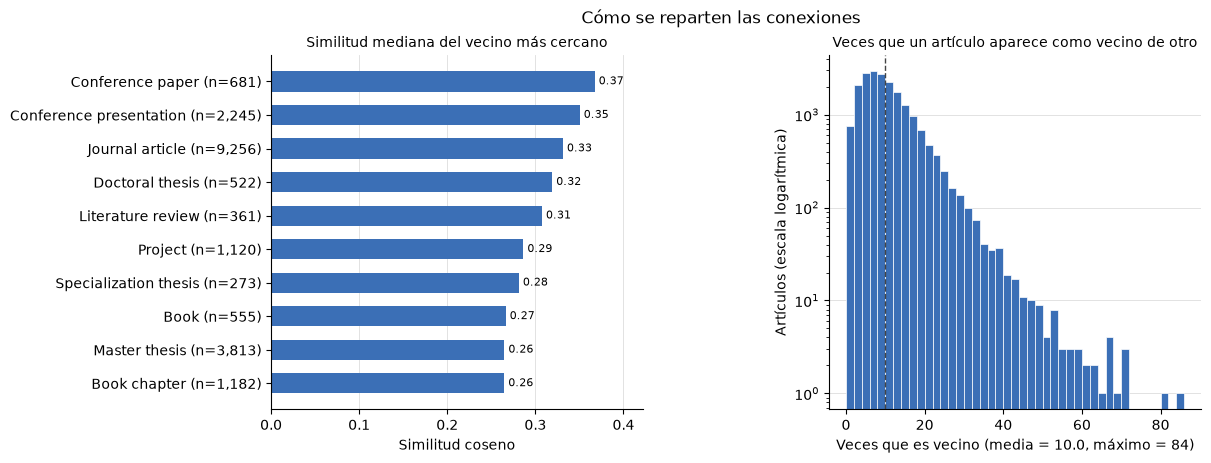

Artículos que no son vecino de ninguno: 218 (1.1%)


In [27]:
MIN_TYPE_SIZE = 200

first_neighbor = tfidf_pairs.loc[tfidf_pairs['rank'] == 1, ['source_idx', 'similarity_score']].copy()
first_neighbor['type'] = tfidf_papers['document_type_normalized'].to_numpy()[first_neighbor['source_idx']]
by_type = first_neighbor.groupby('type')['similarity_score'].agg(['median', 'size'])
by_type = by_type.loc[by_type['size'] >= MIN_TYPE_SIZE].sort_values('median')

times_neighbor = np.bincount(tfidf_pairs['target_idx'], minlength=n_docs)

fig, (ax_type, ax_hub) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={'wspace': 0.5})

type_names = [f'{t.replace("_", " ").capitalize()} (n={n:,})' for t, n in zip(by_type.index, by_type['size'])]
label_bars(ax_type, ax_type.barh(type_names, by_type['median'], color=PLOT_COLOR, height=0.6), fmt='{:.2f}', horizontal=True)
ax_type.set_title('Similitud mediana del vecino más cercano', fontsize=10)
ax_type.set_xlabel('Similitud coseno')
ax_type.margins(x=0.15)
style_axes(ax_type, grid_axis='x')

ax_hub.hist(times_neighbor, bins=np.arange(0, times_neighbor.max() + 3, 2), color=PLOT_COLOR, edgecolor='white', linewidth=0.5)
ax_hub.axvline(times_neighbor.mean(), color='#444444', linewidth=1, linestyle='--')
ax_hub.set_yscale('log')
ax_hub.set_title('Veces que un artículo aparece como vecino de otro', fontsize=10)
ax_hub.set_xlabel(f'Veces que es vecino (media = {times_neighbor.mean():.1f}, máximo = {times_neighbor.max()})')
ax_hub.set_ylabel('Artículos (escala logarítmica)')
style_axes(ax_hub)

fig.suptitle('Cómo se reparten las conexiones', fontsize=12)
plt.show()
print(f'Artículos que no son vecino de ninguno: {(times_neighbor == 0).sum():,} ({(times_neighbor == 0).mean():.1%})')

**Interpretación:** el vecino más cercano de las **tesis** y los **capítulos de libro** es menos parecido que el de los artículos de revista o las ponencias; una posible explicación es que son textos más largos y de temas más variados, aunque no se ha verificado. Respecto a los artículos "populares", la mayoría aparece como vecino unas 10 veces (la media), pero unos pocos aparecen muchas más; por otro lado, cerca de un 1 % no es vecino de nadie. Es un efecto típico de las similitudes por vocabulario y conviene tenerlo presente al construir el grafo.

### Resumen de TF-IDF

- **Configuración:** unigramas, `min_df=3`, `max_df=0.8` (sin efecto: ningún término supera el 32 % de los artículos) y `sublinear_tf`; 20.051 documentos y 25.071 términos en el vocabulario. `colombia` y `colombian` se añadieron a `DOMAIN_STOPWORDS`.
- **Duplicados:** la limpieza elimina primero 90 registros con el mismo título y abstract, y luego 653 más por DOI (620) o por título y año (33). Después quedan 290 pares con similitud ≥ 0,9 para revisar a mano: 90 con el mismo título y distinto año o DOI, y 200 con títulos distintos y abstract casi idéntico.
- **Similitudes:** son bajas en términos absolutos (mediana del vecino más cercano ≈0,31) porque el corpus es muy variado y los abstracts largos comparten pocas palabras. El grafo de vecindad a escala lo muestra: todos los vecinos quedan cerca de similitud 0 y se distinguen por pocas centésimas.
- **Parámetros:** `min_df` apenas cambia los vecinos (≈92-94 % en común). Los bigramas multiplican el vocabulario por 6 y reordenan los vecinos sin traer otros distintos (el vecino más cercano con unigramas está en el top-10 con bigramas en ≈95 % de los casos).
- **Limitaciones:** no hay etiquetas de similitud, así que la calidad de los vecinos no se evalúa; solo se describe con ejemplos. TF-IDF solo compara vocabulario, así que no reconoce sinónimos ni paráfrasis (`car` y `automobile` cuentan como términos distintos). Las conexiones no son simétricas: unos pocos artículos aparecen como vecinos de hasta ≈80 otros y ≈1 % no es vecino de nadie. La sección siguiente, Doc2Vec, intenta cubrir la limitación de vocabulario.
- **Salidas:** `output/tfidf_matrix.npz`, `output/tfidf_paper_ids.csv`, `output/tfidf_similarities.csv`, `output/duplicates_removed.csv` y la tabla `similarities`, que se exporta en `output/similarity_candidates.csv`.

> Las cifras de este resumen corresponden a una ejecución local (Python 3.12, scikit-learn 1.9) con estos parámetros.

## Similitud entre artículos con Doc2Vec

TF-IDF solo compara vocabulario: `car` y `automobile` cuentan como términos distintos. **Doc2Vec** aprende un vector denso por artículo, de modo que dos artículos pueden quedar cerca aunque usen palabras distintas para hablar del mismo tema. La similitud entre dos artículos vuelve a ser el **coseno** de sus vectores.

**Decisiones:**
- **Variante PV-DBOW** (`dm=0`): el vector del artículo se entrena para predecir las palabras que contiene. Suele funcionar mejor que PV-DM en textos cortos como los abstracts y, como los tokens ya no tienen stopwords, el orden de las palabras aporta poco.
- **`dbow_words=1`:** entrena a la vez vectores de palabra (skip-gram). Hace el entrenamiento algo más lento, pero mejora los vectores de documento y permite inspeccionar qué aprendió el modelo.
- **Entrada:** los mismos tokens lematizados y sin stopwords que usa TF-IDF (`tfidf_papers['text_tokens']`). Se usa el índice de fila como etiqueta de cada documento, así los vectores quedan alineados con `tfidf_ids` y con `tfidf_matrix`, y se pueden reusar `top_k_neighbors`, `add_shared_terms` y `show_neighbors`.
- **Palabras en común:** Doc2Vec no dice por qué dos artículos se parecen (sus dimensiones no son palabras). Para cada par se muestran los términos TF-IDF que comparten; si comparten pocos, la conexión es por tema más que por vocabulario.
- **Sin evaluación ni comparación con TF-IDF:** no hay etiquetas de qué artículos son similares, así que esta sección describe el modelo y sus vecinos sin declarar un método ganador. `similarities` sigue saliendo de TF-IDF salvo que `SIMILARITY_METHOD` (configuración inicial) valga `'doc2vec'`.

| Parámetro | Valor | Motivo |
|---|---|---|
| `vector_size` | 100 | Tamaño habitual para corpus de decenas de miles de documentos; más dimensiones necesitan más datos. |
| `window` | 5 | Contexto de los vectores de palabra (`dbow_words=1`). |
| `min_count` | 3 | Igual que `min_df` de TF-IDF: descarta términos de 1-2 artículos. |
| `epochs` | 40 | Doc2Vec necesita más pasadas que Word2Vec; 20-40 es lo usual en corpus de este tamaño. |
| `negative` / `sample` | 5 / 1e-4 | Valores por defecto de gensim para muestreo negativo y submuestreo de palabras frecuentes. |

> gensim solo es determinista con un único hilo. Se entrena con varios para no pasar de unos minutos y se **guarda el modelo** en `output/doc2vec.model`: si existe, se recarga en lugar de reentrenar. Por eso las cifras de las interpretaciones pueden variar un poco entre ejecuciones y se escriben con "≈".

In [28]:
# gensim y umap-learn no vienen preinstalados en Colab; gensim 4.4 funciona con numpy 2 (no hace falta reiniciar).
!pip install -q gensim umap-learn

In [29]:
import os

from gensim.models.doc2vec import Doc2Vec, TaggedDocument

D2V_VECTOR_SIZE = 100
D2V_WINDOW = 5
D2V_MIN_COUNT = TFIDF_MIN_DF      # mismo criterio que TF-IDF para descartar términos raros
D2V_EPOCHS = 40
D2V_NEGATIVE = 5
D2V_SAMPLE = 1e-4
D2V_WORKERS = os.cpu_count() or 1
D2V_RETRAIN = False               # True para ignorar el modelo guardado y volver a entrenar
D2V_MODEL_FILE = Path(OUTPUT_DIR) / 'doc2vec.model'
D2V_VECTORS_FILE = Path(OUTPUT_DIR) / 'd2v_vectors.npy'

# Etiqueta = fila de tfidf_papers, para que model.dv quede alineado con tfidf_ids y tfidf_matrix.
d2v_corpus = [TaggedDocument(tokens.split(), [i]) for i, tokens in enumerate(tfidf_papers['text_tokens'])]

_t0 = time.time()
d2v_model = Doc2Vec.load(str(D2V_MODEL_FILE)) if D2V_MODEL_FILE.is_file() and not D2V_RETRAIN else None
# El modelo guarda los paper_id con los que se entrenó: si el corpus cambió (filtros, deduplicación),
# sus filas ya no corresponden a tfidf_papers y hay que reentrenar.
if d2v_model is not None and not np.array_equal(getattr(d2v_model, 'paper_ids', None), tfidf_ids):
    print('El corpus cambió desde que se guardó el modelo: se reentrena')
    d2v_model = None
if d2v_model is not None:
    print(f'Modelo cargado de {D2V_MODEL_FILE}')
else:
    d2v_model = Doc2Vec(d2v_corpus, dm=0, dbow_words=1, vector_size=D2V_VECTOR_SIZE, window=D2V_WINDOW,
                        min_count=D2V_MIN_COUNT, epochs=D2V_EPOCHS, negative=D2V_NEGATIVE, sample=D2V_SAMPLE,
                        workers=D2V_WORKERS, seed=RANDOM_SEED)
    d2v_model.paper_ids = tfidf_ids
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    d2v_model.save(str(D2V_MODEL_FILE))
    print(f'Entrenamiento: {time.time() - _t0:,.0f} s con {D2V_WORKERS} hilos | guardado: {D2V_MODEL_FILE}')

# Filas normalizadas (L2): el producto punto es el coseno, igual que con tfidf_matrix.
d2v_matrix = d2v_model.dv.vectors.astype(np.float32)
d2v_matrix /= np.linalg.norm(d2v_matrix, axis=1, keepdims=True)
np.save(D2V_VECTORS_FILE, d2v_matrix)

display(pd.Series({
    'Documentos': f'{d2v_matrix.shape[0]:,}',
    'Dimensiones del vector': d2v_matrix.shape[1],
    'Palabras en el vocabulario': f'{len(d2v_model.wv):,}',
}, name='valor').to_frame())
print(f'Guardado: {D2V_VECTORS_FILE} (filas en el orden de {TFIDF_IDS_FILE})')

Modelo cargado de output/doc2vec.model


,valor
Documentos,"20,051"
Dimensiones del vector,100
Palabras en el vocabulario,"32,947"


Guardado: output/d2v_vectors.npy (filas en el orden de output/tfidf_paper_ids.csv)


### Qué aprendió el modelo: palabras cercanas

Con `dbow_words=1` el modelo también aprende un vector por palabra. Las palabras más cercanas a algunos términos del dominio muestran rápidamente si el modelo capta relaciones con sentido (sinónimos, términos del mismo campo) o solo ruido.

In [30]:
PROBE_WORDS = ['learning', 'crop', 'patient', 'concrete', 'water', 'energy']
N_SIMILAR_WORDS = 8

probes = [w for w in PROBE_WORDS if w in d2v_model.wv.key_to_index]
missing = sorted(set(PROBE_WORDS) - set(probes))
if missing:
    print(f'Fuera del vocabulario (se omiten): {missing}')

display(pd.DataFrame({
    word: [f'{w} ({s:.2f})' for w, s in d2v_model.wv.most_similar(word, topn=N_SIMILAR_WORDS)]
    for word in probes
}, index=pd.RangeIndex(1, N_SIMILAR_WORDS + 1, name='rank')))

,learning,crop,patient,concrete,water,energy
rank,,,,,,
1,learn (0.90),cultivation (0.76),clinical (0.76),shotcrete (0.75),bakurukar (0.63),renewable (0.75)
2,machine (0.80),sown (0.75),adenoamigdalectomy (0.76),workingability (0.75),supply (0.61),gasifier (0.73)
3,medl (0.73),pest (0.71),operativesars (0.75),diammonium (0.74),rwc (0.60),electricity (0.70)
4,teaching (0.70),phytosanitary (0.69),mcrpc (0.75),3dp (0.74),drinking (0.60),sources (0.69)
5,pytorch (0.69),agricultural (0.69),appendicectomy (0.74),mortar (0.73),irh (0.60),generation (0.69)
6,qmc (0.69),pisum (0.68),tka (0.74),rca (0.71),tabasco (0.60),collisionless (0.68)
7,cscl (0.69),preharvest (0.68),covidd-19 (0.74),c39 (0.70),groundwater (0.60),prosumer (0.65)
8,meaningful (0.68),staple (0.68),utip (0.74),durability (0.70),wac (0.60),fncer (0.65)


**Interpretación:** para los términos frecuentes el modelo aprendió relaciones del dominio. `crop` queda junto a `cultivation`, `sown`, `pest`, `phytosanitary`, `agricultural` y `preharvest`; `concrete` junto a `shotcrete`, `mortar` y `durability`; `energy` junto a `renewable`, `gasifier`, `electricity` y `generation`; `learning` junto a `learn`, `machine`, `teaching` y `pytorch`. Son justo las relaciones que TF-IDF no ve, porque para TF-IDF `crop` y `cultivation` son términos sin relación. El ruido viene de **términos raros**: con `min_count=3` una sigla o una errata que aparece en 3 o 4 artículos recibe un vector aprendido de muy pocos contextos y puede quedar muy cerca de cualquier palabra de esos artículos (`tka`, `utip`, `covidd-19` junto a `patient`; `bakurukar`, `tabasco` junto a `water`). `water`, al ser un término muy general, es el que tiene los vecinos menos claros (similitudes ≈0,60-0,63).

### Vecinos más similares

Se reusa `top_k_neighbors` con la matriz densa de Doc2Vec y `add_shared_terms` con la matriz TF-IDF para las palabras en común. La escala del coseno de Doc2Vec no es la de TF-IDF (los vectores densos casi nunca son ortogonales), así que el umbral `D2V_MIN_SIMILARITY` se fija aparte mirando los percentiles.

In [31]:
D2V_MIN_SIMILARITY = MIN_SIMILARITY     # la similitud mínima observada es ≈0,44: no filtra ningún par
D2V_SIMILARITIES_FILE = Path(OUTPUT_DIR) / 'd2v_similarities.csv'

_t0 = time.time()
d2v_pairs = top_k_neighbors(d2v_matrix, tfidf_ids, min_similarity=D2V_MIN_SIMILARITY)
d2v_pairs = add_shared_terms(d2v_pairs, tfidf_matrix, tfidf_vocabulary)
print(f'Vecinos calculados en {time.time() - _t0:,.0f} s')
print(f'Pares (artículo, vecino): {len(d2v_pairs):,} | '
      f'artículos con al menos un vecino: {d2v_pairs["source_idx"].nunique():,} de {n_docs:,}')

d2v_similarities = d2v_pairs[['paper_id_1', 'paper_id_2', 'similarity_score', 'rank', 'shared_terms']].copy()
d2v_similarities['similarity_score'] = d2v_similarities['similarity_score'].round(4)
d2v_similarities.insert(4, 'method', 'doc2vec')
d2v_similarities.to_csv(D2V_SIMILARITIES_FILE, index=False, encoding='utf-8-sig')
print(f'Guardado: {D2V_SIMILARITIES_FILE} ({len(d2v_similarities):,} pares)')

no_shared = d2v_pairs['shared_terms'].eq('').mean()
print(f'Pares sin ninguna palabra TF-IDF en común: {no_shared:.1%}')
display(d2v_pairs.groupby(d2v_pairs['rank'].eq(1).map({True: 'rank 1', False: 'resto del top-k'}))['similarity_score']
        .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3))

Vecinos calculados en 12 s
Pares (artículo, vecino): 200,510 | artículos con al menos un vecino: 20,051 de 20,051


Guardado: output/d2v_similarities.csv (200,510 pares)
Pares sin ninguna palabra TF-IDF en común: 1.4%


,count,mean,std,min,5%,25%,50%,75%,95%,max
rank,,,,,,,,,,
rank 1,20051.0,0.676,0.093,0.484,0.564,0.613,0.656,0.715,0.875,0.994
resto del top-k,180459.0,0.598,0.060,0.438,0.517,0.558,0.589,0.627,0.707,0.991


**Interpretación:** las similitudes de Doc2Vec están en otra escala que las de TF-IDF: van de ≈0,44 a ≈0,99, con mediana del vecino más cercano ≈0,66. Por eso `MIN_SIMILARITY = 0.10` no filtra nada y los 20.051 artículos tienen sus 10 vecinos. Sin etiquetas no hay un criterio para fijar otro umbral; si estas aristas se usan en el grafo, habrá que decidirlo con otro criterio. Tres observaciones:

- **Casi todas las conexiones comparten vocabulario:** en ≈82 % de los pares los dos artículos comparten al menos 5 términos TF-IDF (el máximo que se guarda) y solo en ≈1,4 % no comparten ninguno. Aunque Doc2Vec puede conectar por tema sin palabras en común, en este corpus la mayoría de sus vecinos también son vecinos por vocabulario.
- **Casi duplicados:** ≈815 artículos tienen un vecino más cercano con similitud ≥ 0,9 (≈490 pares distintos). Son casos parecidos a los que encontró TF-IDF: el mismo trabajo con otro registro o abstract casi idéntico.
- **Artículos "populares":** un mismo artículo aparece como vecino de hasta ≈210 artículos, y el 1 % más frecuente aparece más de ≈54 veces. Es el efecto *hub* típico de los vectores densos, que concentra conexiones en unos pocos nodos del grafo.

> Las cifras de casi duplicados, palabras en común y artículos populares se calcularon aparte sobre `output/d2v_similarities.csv`.

#### Ejemplos cualitativos

Los mismos tres artículos de ejemplo de la sección de TF-IDF (`EXAMPLE_PAPER_IDS`), con sus vecinos según Doc2Vec y las palabras que comparten.

In [32]:
for paper_id in EXAMPLE_PAPER_IDS:
    if paper_id not in tfidf_titles.index:
        print(f'\n{paper_id}: no está en el corpus (¿cambió el dataset o los filtros?)')
        continue
    print()
    show_neighbors(paper_id, d2v_pairs, n=N_EXAMPLE_NEIGHBORS)


HORUS_000123: Advancing healthcare analytics: a thematic review of machine learning, health informatics, and real-world data applications


,rank,similitud,vecino,términos compartidos
0,1,0.663,Trends in Business Analytics Education: Innova...,"analytic, theme, learning, ethical, innovation"
1,2,0.622,Revolutionizing Data Exchange Through Intellig...,"ai, ethical, intelligent, interoperability, pr..."
2,3,0.620,Emerging trends and strategic opportunities in...,"thematic, ai, learning, privacy, theme"
3,4,0.612,COMPARATIVE EVALUATION OF ALGORITHMS FOR ADAPT...,"analytic, adaptive, insight, learn, review"
4,5,0.610,Emerging Trends in Retail Analytics: A Bibliom...,"analytic, trend, scopus, data, emerge"



HORUS_000037: Isolation and identification of antimicrobial compounds produced by Bacillus nakamurai CBAS-959 and their activity against phytopathogenic bacteria


,rank,similitud,vecino,términos compartidos
0,1,0.602,BIODIRIGID OXANDRA LONGIPETALA (ANNONACAE) FRA...,"phytopathogenic, fraction, extract, inhibit, s..."
1,2,0.599,Garcinia madruno (Kunth) Hammel[Antimicrobial ...,"extract, antimicrobial, bacteria, compound, μg"
2,3,0.588,"Caerulines A and B, Flavonol Diacylglycosides ...","mic, μg, compound, ml, extract"
3,4,0.585,Antiquorum and Antibiofilm Activities of Piper...,"inhibition, assay, extract, compound, fraction"
4,5,0.582,Theobroma cacao (L.) In vitro evaluation of co...,"compound, growth, produce, co, activity"



HORUS_000010: Transition clinics in pediatric rheumatology in Colombia: reflection on a necessary shortcomings


,rank,similitud,vecino,términos compartidos
0,1,0.651,Design and implementation of the Comprehensive...,"care, implementation, comprehensive, patient, ..."
1,2,0.615,HYGHLIGHT IN THE NUTRITIONAL ONCOLOGY IN PEDIA...,"pediatric, care, patient, intervention, process"
2,3,0.603,INTERVENTIONS FOR FAMILY CAREERS OF PALIAL CAR...,"intervention, family, care, development"
3,4,0.597,DISEASE INTERVENTION TO BRAIN SOCIAL SUPPORT T...,"disease, chronic, family, support, intervention"
4,5,0.591,TALKER 2 VALUE SCALES IN NEUROMUSCULAR DISEASE,"adulthood, disease, childhood, implementation,..."


**Interpretación:** la coherencia de los vecinos depende de lo específico que sea el tema del artículo:

- **Compuestos antimicrobianos contra fitopatógenos (`HORUS_000037`):** los 5 vecinos estudian extractos o compuestos naturales con actividad antimicrobiana (fracciones de *Oxandra*, *Garcinia*, *Piper*, cacao). Doc2Vec generaliza al tema "actividad antimicrobiana de productos naturales", no solo a bacterias de plantas; las palabras en común son las del método experimental (`extract`, `compound`, `inhibition`, `μg`).
- **Clínicas de transición en reumatología pediátrica (`HORUS_000010`):** los vecinos son del tema amplio de **atención a pacientes crónicos** (atención integral, oncología pediátrica, cuidados paliativos y familia, enfermedad neuromuscular de la infancia a la adultez), no de reumatología. Los conecta vocabulario general de cuidado (`care`, `intervention`, `family`, `chronic`).
- **Revisión sobre analítica en salud (`HORUS_000123`):** los vecinos son otras **revisiones de tendencias en analítica e inteligencia artificial** (educación en analítica de negocios, intercambio inteligente de datos, retail). Doc2Vec agrupa aquí por el **tipo de texto** (revisión temática, `trend`, `scopus`, `analytic`) más que por el dominio.

### Resumen de Doc2Vec

- **Configuración:** PV-DBOW con vectores de palabra (`dm=0`, `dbow_words=1`), `vector_size=100`, `window=5`, `min_count=3`, `epochs=40`; mismos 20.051 documentos y tokens que TF-IDF. El entrenamiento tardó ≈2 min con 10 hilos y el vocabulario quedó en 32.947 palabras. El modelo guarda los `paper_id` con los que se entrenó y se reentrena solo si el corpus cambia.
- **Vocabulario aprendido:** los términos frecuentes quedan junto a palabras del mismo campo (`concrete` → `shotcrete`, `mortar`; `crop` → `cultivation`, `pest`, `agricultural`), que es lo que TF-IDF no puede capturar. Los términos raros (siglas y erratas de 3-4 artículos) generan vecinos ruidosos.
- **Vecinos:** similitudes entre ≈0,44 y ≈0,99, con mediana del vecino más cercano ≈0,66; el umbral de 0,10 no filtra nada. En ≈82 % de los pares los artículos comparten al menos 5 términos TF-IDF y solo ≈1,4 % no comparte ninguno. Hay ≈490 pares de casi duplicados (≥ 0,9) y un efecto *hub*: un artículo aparece como vecino de ≈210 artículos.
- **Ejemplos:** coherentes cuando el tema es específico (actividad antimicrobiana de productos naturales). Cuando el tema es amplio, agrupan por tema general (atención a pacientes crónicos) o por tipo de texto (revisiones de tendencias).
- **Limitaciones:** no hay etiquetas para evaluar si los vecinos son buenos, así que la sección es descriptiva y no se compara con TF-IDF. Los vectores no son interpretables (la explicación viene de las palabras TF-IDF en común), el entrenamiento con varios hilos no es exactamente reproducible (por eso se guarda el modelo) y durante el entrenamiento gensim 4.4 imprime avisos `Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'` que no lo detienen.
- **Salidas:** `output/doc2vec.model`, `output/d2v_vectors.npy` (filas en el orden de `output/tfidf_paper_ids.csv`) y `output/d2v_similarities.csv`. `similarities` sigue saliendo de TF-IDF salvo que `SIMILARITY_METHOD = 'doc2vec'`.

> Las cifras de esta sección corresponden a una ejecución local (Python 3.12, gensim 4.4, scikit-learn 1.9) con estos parámetros; en Colab pueden variar ligeramente porque el entrenamiento con varios hilos no es determinista. Los datos marcados como "calculado aparte" se obtuvieron fuera del notebook.

## Agrupamiento de artículos con K-Means: Doc2Vec

En esta sección se implementan las fases 0–3 del agrupamiento de los vectores Doc2Vec. Se conserva la configuración experimental de TF-IDF: **K = 2–10**, **100 corridas independientes por K**, inicialización `k-means++`, una inicialización por corrida y la misma métrica euclídea para K-Means y sus métricas de evaluación. Cada corrida usa una semilla reproducible derivada de `RANDOM_SEED`.

**Referencia metodológica:** Etapa 3 (Agrupación) de [Entrega-3.ipynb](https://github.com/Locotin/data-mining/blob/main/Proyecto/Entrega-3.ipynb). Se replican sus métricas, sus corridas y su forma de elegir y caracterizar los clusters.

Doc2Vec ya entrega vectores L2-normalizados y alineados por artículo con `tfidf_ids`. No se vuelve a entrenar ni a transformar el modelo: K-Means trabaja directamente sobre `d2v_matrix`. La fase 3 propone un K equilibrando silueta y Davies–Bouldin; la elección final debe contrastarse también con el codo y la interpretación temática de los grupos.

Las fases 4 y 5 quedan como etapas siguientes: ajustar el modelo final con el K elegido y caracterizar sus grupos.

### Fase 0: preparación de la entrada Doc2Vec

Se verifica que exista un vector finito y normalizado por cada artículo y se calcula la suma de cuadrados total (SST), necesaria para obtener la variación entre grupos (SSB = SST − SSW). Como los vectores ya están normalizados, se usan directamente sin reducir dimensiones.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

D2V_KMEANS_K_VALUES = tuple(range(2, 11))
D2V_KMEANS_N_RUNS = 100
D2V_KMEANS_N_INIT = 1
D2V_KMEANS_MAX_ITER = 300
D2V_KMEANS_RUNS_FILE = Path(OUTPUT_DIR) / 'd2v_kmeans_runs.csv'
D2V_KMEANS_SUMMARY_FILE = Path(OUTPUT_DIR) / 'd2v_kmeans_summary.csv'

D2V_KMEANS_X = np.ascontiguousarray(d2v_matrix, dtype=np.float32)
if D2V_KMEANS_X.ndim != 2 or D2V_KMEANS_X.shape[0] != len(tfidf_ids):
    raise ValueError('d2v_matrix y tfidf_ids no contienen el mismo número de artículos')
if not np.isfinite(D2V_KMEANS_X).all():
    raise ValueError('d2v_matrix contiene valores no finitos; no se puede ejecutar K-Means')

d2v_norms = np.linalg.norm(D2V_KMEANS_X, axis=1)
if not np.allclose(d2v_norms, 1.0, atol=1e-4):
    raise ValueError('Se esperaban vectores Doc2Vec L2-normalizados')
if D2V_KMEANS_X.shape[0] <= max(D2V_KMEANS_K_VALUES):
    raise ValueError('Se necesitan más artículos que el mayor K evaluado')

D2V_KMEANS_TOTAL_SS = float(np.square(
    D2V_KMEANS_X.astype(np.float64) - D2V_KMEANS_X.mean(axis=0, dtype=np.float64)
).sum())
if D2V_KMEANS_TOTAL_SS <= 0:
    raise ValueError('La variación total de Doc2Vec es nula; no se puede calcular SSB / SST')

display(pd.Series({
    'Artículos': f'{D2V_KMEANS_X.shape[0]:,}',
    'Dimensiones Doc2Vec': D2V_KMEANS_X.shape[1],
    'K evaluados': f'{min(D2V_KMEANS_K_VALUES)}–{max(D2V_KMEANS_K_VALUES)}',
    'Corridas por K': D2V_KMEANS_N_RUNS,
    'SST total': f'{D2V_KMEANS_TOTAL_SS:,.4f}',
}, name='valor').to_frame())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), layout='constrained')

norm_summary = pd.Series(d2v_norms)
axes[0].hist(norm_summary, bins=35, color=PLOT_COLOR, alpha=0.85, edgecolor='white')
axes[0].axvline(1.0, color='#D55E00', linestyle='--', linewidth=1.5, label='norma esperada')
axes[0].set_title('Norma L2 de los vectores Doc2Vec', fontsize=10)
axes[0].set_xlabel('Norma')
axes[0].set_ylabel('Artículos')
axes[0].legend(frameon=False, fontsize=8)
style_axes(axes[0])

dimension_data = pd.Series({'Artículos': D2V_KMEANS_X.shape[0], 'Dimensiones': D2V_KMEANS_X.shape[1]})
bars = axes[1].bar(dimension_data.index, dimension_data.values, color=[PLOT_COLOR, '#DE8F05'], width=0.55)
label_bars(axes[1], bars)
axes[1].set_title('Tamaño de la entrada', fontsize=10)
axes[1].set_ylabel('Cantidad')
axes[1].margins(y=0.18)
style_axes(axes[1])

centered_var = np.var(D2V_KMEANS_X, axis=0)
axes[2].plot(np.arange(1, len(centered_var) + 1), np.sort(centered_var)[::-1], color=PLOT_COLOR, linewidth=1.8)
axes[2].fill_between(np.arange(1, len(centered_var) + 1), 0, np.sort(centered_var)[::-1], color=PLOT_COLOR, alpha=0.14)
axes[2].set_title('Varianza por dimensión Doc2Vec', fontsize=10)
axes[2].set_xlabel('Dimensión ordenada por varianza')
axes[2].set_ylabel('Varianza')
style_axes(axes[2])

fig.suptitle('Fase 0 - Revisión visual de la matriz de entrada Doc2Vec', fontsize=12)
plt.show()


### Fase 1: evaluación de K-Means en Doc2Vec

Se ejecutan las 100 corridas por cada K de 2 a 10. Cada una utiliza `k-means++`, `n_init=1`, `max_iter=300` y una semilla distinta; se guardan SSW, SSB, su proporción de SST, silueta y Davies–Bouldin.

In [ ]:
d2v_kmeans_records = []
for k in D2V_KMEANS_K_VALUES:
    for run in range(D2V_KMEANS_N_RUNS):
        seed = RANDOM_SEED + run
        model = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=D2V_KMEANS_N_INIT,
            max_iter=D2V_KMEANS_MAX_ITER,
            random_state=seed,
        )
        labels = model.fit_predict(D2V_KMEANS_X)
        ssw = float(model.inertia_)
        ssb = max(D2V_KMEANS_TOTAL_SS - ssw, 0.0)
        d2v_kmeans_records.append({
            'k': k,
            'run': run + 1,
            'seed': seed,
            'ssw': ssw,
            'ssb': ssb,
            'ssb_ratio': ssb / D2V_KMEANS_TOTAL_SS,
            'silhouette': float(silhouette_score(D2V_KMEANS_X, labels, metric='euclidean')),
            'davies_bouldin': float(davies_bouldin_score(D2V_KMEANS_X, labels)),
            'iterations': int(model.n_iter_),
        })
    print(f'K={k}: {D2V_KMEANS_N_RUNS} corridas completas')

d2v_kmeans_runs = pd.DataFrame(d2v_kmeans_records)
d2v_kmeans_runs.to_csv(D2V_KMEANS_RUNS_FILE, index=False)
print(f'Corridas guardadas: {D2V_KMEANS_RUNS_FILE}')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout='constrained')
run_metrics = [
    ('ssw', 'SSW por corrida', 'Menor es mejor'),
    ('ssb_ratio', 'SSB / SST por corrida', 'Mayor separación'),
    ('silhouette', 'Silueta por corrida', 'Mayor es mejor'),
    ('davies_bouldin', 'Davies-Bouldin por corrida', 'Menor es mejor'),
]
rng = np.random.default_rng(RANDOM_SEED)
jitter = rng.normal(0, 0.055, size=len(d2v_kmeans_runs))
for ax, (metric, title, note) in zip(axes.flat, run_metrics):
    ax.scatter(d2v_kmeans_runs['k'] + jitter, d2v_kmeans_runs[metric], s=10, alpha=0.22,
               color=PLOT_COLOR, linewidths=0)
    med = d2v_kmeans_runs.groupby('k')[metric].median()
    ax.plot(med.index, med.values, color='#D55E00', marker='o', linewidth=1.8, markersize=4, label='mediana')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Número de grupos (K)')
    ax.set_xticks(D2V_KMEANS_K_VALUES)
    ax.text(0.98, 0.97, note, transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#555555')
    style_axes(ax)
fig.suptitle('Fase 1 - Dispersión de las 100 corridas por K en Doc2Vec', fontsize=12)
plt.show()


### Fase 2: resumen e interpretación de métricas

Se presentan media, desviación estándar, mínimo y máximo de cada métrica por K. Las curvas permiten observar el codo de SSW, el aumento de SSB, la separación de silueta, la compacidad de Davies–Bouldin y la estabilidad entre semillas. SSB tiende a crecer con K, por lo que no se interpreta por sí sola como criterio para elegirlo.

In [ ]:
d2v_kmeans_metrics = ['ssw', 'ssb', 'ssb_ratio', 'silhouette', 'davies_bouldin']
d2v_kmeans_summary = d2v_kmeans_runs.groupby('k').agg(
    runs=('run', 'count'),
    **{
        f'{metric}_{stat}': (metric, stat)
        for metric in d2v_kmeans_metrics
        for stat in ('mean', 'std', 'min', 'max')
    },
)
d2v_kmeans_summary.to_csv(D2V_KMEANS_SUMMARY_FILE)
display(d2v_kmeans_summary.round(4))
print(f'Resumen guardado: {D2V_KMEANS_SUMMARY_FILE}')

plot_metrics = [
    ('ssw', 'SSW (variación dentro de grupos)', 'Suma de cuadrados'),
    ('ssb_ratio', 'SSB / SST (variación explicada)', 'Proporción de SST'),
    ('silhouette', 'Silueta (mayor es mejor)', 'Coeficiente'),
    ('davies_bouldin', 'Davies–Bouldin (menor es mejor)', 'Índice'),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (metric, title, ylabel) in zip(axes.flat, plot_metrics):
    means = d2v_kmeans_summary[f'{metric}_mean']
    stds = d2v_kmeans_summary[f'{metric}_std'].fillna(0)
    ax.errorbar(means.index, means, yerr=stds, marker='o', capsize=4, linewidth=2)
    ax.set(title=title, xlabel='Número de grupos (K)', ylabel=ylabel)
    ax.set_xticks(D2V_KMEANS_K_VALUES)
    ax.grid(alpha=0.25)
fig.suptitle('Doc2Vec — K-Means: media ± desviación estándar (100 corridas por K)', fontsize=14)
fig.tight_layout()
plt.show()

### Fase 3: selección del K candidato

La mejor corrida de cada K es la de menor SSW; los empates se resuelven con mayor silueta y menor Davies–Bouldin. Para proponer un candidato equilibrado, se promedian los rangos de silueta y Davies–Bouldin entre los K (ambas métricas tienen el mismo peso). La SSW se usa para leer el codo, no para rankear K, pues siempre puede reducirse al aumentar grupos. La propuesta estadística se debe validar inspeccionando artículos y temas de los grupos.

In [ ]:
d2v_kmeans_best_runs = (
    d2v_kmeans_runs
    .sort_values(['k', 'ssw', 'silhouette', 'davies_bouldin'],
                ascending=[True, True, False, True], kind='stable')
    .groupby('k', as_index=False)
    .first()
)
d2v_kmeans_candidates = d2v_kmeans_summary[[
    'ssw_mean', 'ssb_ratio_mean', 'silhouette_mean', 'silhouette_std',
    'davies_bouldin_mean', 'davies_bouldin_std',
]].copy()
d2v_kmeans_candidates['silhouette_rank'] = d2v_kmeans_candidates['silhouette_mean'].rank(
    ascending=False, method='min')
d2v_kmeans_candidates['davies_bouldin_rank'] = d2v_kmeans_candidates['davies_bouldin_mean'].rank(
    ascending=True, method='min')
d2v_kmeans_candidates['rank_average'] = d2v_kmeans_candidates[
    ['silhouette_rank', 'davies_bouldin_rank']
].mean(axis=1)
d2v_kmeans_candidates = d2v_kmeans_candidates.sort_values(
    ['rank_average', 'silhouette_mean', 'davies_bouldin_mean'],
    ascending=[True, False, True],
)
D2V_KMEANS_RECOMMENDED_K = int(d2v_kmeans_candidates.index[0])

display(d2v_kmeans_best_runs[[
    'k', 'run', 'seed', 'ssw', 'ssb_ratio', 'silhouette', 'davies_bouldin'
]].set_index('k').round(4).rename(columns={
    'run': 'mejor_corrida',
    'seed': 'semilla',
    'ssw': 'SSW',
    'ssb_ratio': 'SSB / SST',
    'silhouette': 'silueta',
    'davies_bouldin': 'Davies-Bouldin',
}))
display(d2v_kmeans_candidates.rename(columns={
    'ssw_mean': 'SSW media',
    'ssb_ratio_mean': 'SSB / SST media',
    'silhouette_mean': 'silueta media',
    'silhouette_std': 'silueta desv.',
    'davies_bouldin_mean': 'Davies-Bouldin medio',
    'davies_bouldin_std': 'Davies-Bouldin desv.',
    'silhouette_rank': 'rango silueta',
    'davies_bouldin_rank': 'rango DB',
    'rank_average': 'rango medio',
}).round(4))

silhouette_k = int(d2v_kmeans_summary['silhouette_mean'].idxmax())
davies_bouldin_k = int(d2v_kmeans_summary['davies_bouldin_mean'].idxmin())
ssw_first = float(d2v_kmeans_summary.loc[min(D2V_KMEANS_K_VALUES), 'ssw_mean'])
ssw_last = float(d2v_kmeans_summary.loc[max(D2V_KMEANS_K_VALUES), 'ssw_mean'])
ssw_reduction = 100 * (ssw_first - ssw_last) / ssw_first if ssw_first else 0.0
candidate_row = d2v_kmeans_summary.loc[D2V_KMEANS_RECOMMENDED_K]
display(Markdown(f'''### Análisis de resultados — Doc2Vec

- **Candidato equilibrado:** K = {D2V_KMEANS_RECOMMENDED_K}, con el mejor rango medio entre silueta y Davies–Bouldin.
- **Mayor silueta media:** K = {silhouette_k} ({d2v_kmeans_summary.loc[silhouette_k, 'silhouette_mean']:.4f}); **menor Davies–Bouldin medio:** K = {davies_bouldin_k} ({d2v_kmeans_summary.loc[davies_bouldin_k, 'davies_bouldin_mean']:.4f}). Si estos K no coinciden, comparar esos candidatos con el K recomendado y el codo.
- **Compacidad:** la SSW media disminuye {ssw_reduction:.1f}% entre K = {min(D2V_KMEANS_K_VALUES)} y K = {max(D2V_KMEANS_K_VALUES)}. El punto en que esa reducción empieza a ser menos pronunciada ayuda a identificar el codo; la mejora de SSW por sí sola no justifica aumentar K.
- **Estabilidad en el candidato:** desviación estándar de silueta = {candidate_row['silhouette_std']:.4f} y de Davies–Bouldin = {candidate_row['davies_bouldin_std']:.4f} entre las 100 semillas.

**Conclusión provisional:** usar K = {D2V_KMEANS_RECOMMENDED_K} como candidato para el modelo de referencia, no como verdad temática. Doc2Vec representa similitud semántica en un espacio denso, pero las métricas internas no sustituyen la revisión de títulos, artículos cercanos al centroide y composición de cada grupo. La decisión final debe comprobar que los grupos sean coherentes y útiles para la clasificación.'''))

In [ ]:
phase3_scores = pd.DataFrame(index=d2v_kmeans_summary.index)
phase3_scores['Silueta'] = d2v_kmeans_summary['silhouette_mean']
phase3_scores['SSB / SST'] = d2v_kmeans_summary['ssb_ratio_mean']
phase3_scores['SSW'] = -d2v_kmeans_summary['ssw_mean']
phase3_scores['Davies-Bouldin'] = -d2v_kmeans_summary['davies_bouldin_mean']
phase3_scores = (phase3_scores - phase3_scores.min()) / (phase3_scores.max() - phase3_scores.min())
phase3_scores = phase3_scores.fillna(1.0)

fig, ax = plt.subplots(figsize=(10.5, 4.3), layout='constrained')
im = ax.imshow(phase3_scores.T, cmap='viridis', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(np.arange(len(phase3_scores.index)), [f'K={k}' for k in phase3_scores.index])
ax.set_yticks(np.arange(len(phase3_scores.columns)), phase3_scores.columns)
ax.set_title('Fase 3 - Comparación normalizada de criterios para elegir K', fontsize=11)
for y in range(phase3_scores.shape[1]):
    for x in range(phase3_scores.shape[0]):
        ax.text(x, y, f'{phase3_scores.iloc[x, y]:.2f}', ha='center', va='center', color='white', fontsize=8)
ax.scatter([list(phase3_scores.index).index(D2V_KMEANS_RECOMMENDED_K)], [-0.62], marker='v', s=90,
           color='#D55E00', clip_on=False)
ax.text(list(phase3_scores.index).index(D2V_KMEANS_RECOMMENDED_K), -0.92,
        f'K recomendado = {D2V_KMEANS_RECOMMENDED_K}', ha='center', va='top', fontsize=9, color='#D55E00')
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Puntaje relativo (más alto = mejor)', fontsize=9)
plt.show()


### Fase 4: modelo de referencia

Se ajusta el modelo final de Doc2Vec con el K recomendado en la fase 3 y varias inicializaciones (`n_init=50`). Esta corrida ya no es una corrida exploratoria: es el modelo de referencia que produce la clasificación final de cada artículo. Se reportan sus métricas y se guarda, para cada artículo, el cluster asignado y la distancia al centroide.


In [ ]:
D2V_KMEANS_REFERENCE_N_INIT = 50
D2V_KMEANS_CLUSTERS_FILE = Path(OUTPUT_DIR) / 'd2v_kmeans_clusters.csv'
D2V_KMEANS_K = D2V_KMEANS_RECOMMENDED_K

d2v_reference_model = KMeans(
    n_clusters=D2V_KMEANS_K,
    init='k-means++',
    n_init=D2V_KMEANS_REFERENCE_N_INIT,
    max_iter=D2V_KMEANS_MAX_ITER,
    random_state=RANDOM_SEED + D2V_KMEANS_K * 100_000,
).fit(D2V_KMEANS_X)

raw_labels = d2v_reference_model.labels_
cluster_order = np.argsort(-np.bincount(raw_labels, minlength=D2V_KMEANS_K))
cluster_rank = np.empty(D2V_KMEANS_K, dtype=int)
cluster_rank[cluster_order] = np.arange(D2V_KMEANS_K)
d2v_cluster_labels = cluster_rank[raw_labels]
d2v_cluster_centers = d2v_reference_model.cluster_centers_[cluster_order]
d2v_cluster_distance = np.linalg.norm(D2V_KMEANS_X - d2v_cluster_centers[d2v_cluster_labels], axis=1)

d2v_reference_metrics = pd.Series({
    'K final': D2V_KMEANS_K,
    'SSW': float(d2v_reference_model.inertia_),
    'SSB / SST': max(D2V_KMEANS_TOTAL_SS - float(d2v_reference_model.inertia_), 0.0) / D2V_KMEANS_TOTAL_SS,
    'Silueta': float(silhouette_score(D2V_KMEANS_X, d2v_cluster_labels, metric='euclidean')),
    'Davies-Bouldin': float(davies_bouldin_score(D2V_KMEANS_X, d2v_cluster_labels)),
    'Inicializaciones': D2V_KMEANS_REFERENCE_N_INIT,
}, name='valor')
display(d2v_reference_metrics.to_frame())

d2v_clusters = pd.DataFrame({
    'paper_id': tfidf_ids,
    'cluster': d2v_cluster_labels + 1,
    'distancia_centroide': np.round(d2v_cluster_distance, 4),
})
d2v_clusters.to_csv(D2V_KMEANS_CLUSTERS_FILE, index=False)
print(f'Clusters guardados: {D2V_KMEANS_CLUSTERS_FILE}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')
reference_sizes = pd.Series(np.bincount(d2v_cluster_labels), index=[f'Cluster {i + 1}' for i in range(D2V_KMEANS_K)])
bars = axes[0].bar(reference_sizes.index, reference_sizes.values, color=PLOT_COLOR, width=0.62)
label_bars(axes[0], bars)
axes[0].set_title('Tamaño de los clusters finales', fontsize=10)
axes[0].set_ylabel('Artículos')
axes[0].tick_params(axis='x', rotation=35)
axes[0].margins(y=0.18)
style_axes(axes[0])

metric_compare = pd.DataFrame({
    'modelo final': [d2v_reference_metrics['Silueta'], d2v_reference_metrics['Davies-Bouldin']],
    'promedio corridas': [
        d2v_kmeans_summary.loc[D2V_KMEANS_K, 'silhouette_mean'],
        d2v_kmeans_summary.loc[D2V_KMEANS_K, 'davies_bouldin_mean'],
    ],
}, index=['Silueta', 'Davies-Bouldin'])
metric_compare.plot(kind='bar', ax=axes[1], color=[PLOT_COLOR, '#949494'], width=0.72)
axes[1].set_title('Modelo final vs. promedio de corridas', fontsize=10)
axes[1].set_ylabel('Valor')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(frameon=False, fontsize=8)
style_axes(axes[1])

fig.suptitle('Fase 4 - Modelo de referencia Doc2Vec', fontsize=12)
plt.show()


In [ ]:
display(Markdown(f'''**Interpretación:** el modelo final usa **K = {D2V_KMEANS_K}** y asigna todos los artículos a un cluster. La gráfica de tamaños permite ver si la clasificación quedó balanceada o si existe un grupo dominante; la comparación de métricas indica si el modelo de referencia mejora o mantiene el comportamiento promedio de las 100 corridas exploratorias. La distancia al centroide sirve para separar artículos representativos (cerca del centro) de artículos frontera (lejos del centro).'''))


### Fase 5: caracterización de los clusters (clasificación)

Se caracteriza cada cluster final con información interpretable: tamaño, términos TF-IDF que más lo distinguen frente al resto del corpus, tipo de documento, revistas frecuentes, año mediano y artículos más cercanos al centroide. Con esos elementos se asigna un nombre descriptivo a cada cluster; ese nombre queda guardado como la clasificación final.


In [ ]:
D2V_CLUSTER_TOP_TERMS = 8
D2V_CLUSTER_REPRESENTATIVE = 3
D2V_CLUSTER_TYPE_TOP = 5
D2V_CLUSTER_COLORS = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161', '#949494', '#56B4E9', '#ECE133', '#FBAFE4']


def cluster_tfidf_terms(labels, matrix=tfidf_matrix, vocabulary=tfidf_vocabulary, n_terms=D2V_CLUSTER_TOP_TERMS):
    labels = np.asarray(labels)
    k = labels.max() + 1
    n = len(labels)
    onehot = sparse.csr_matrix((np.ones(n), (np.arange(n), labels)), shape=(n, k))
    sizes = np.bincount(labels, minlength=k)[:, None]
    present = (matrix > 0).astype(np.float32)
    weight_in = np.asarray((onehot.T @ matrix).todense()) / sizes
    share_in = np.asarray((onehot.T @ present).todense()) / sizes
    weight_out = (np.asarray(matrix.sum(axis=0)) - weight_in * sizes) / (n - sizes)
    share_out = (np.asarray(present.sum(axis=0)) - share_in * sizes) / (n - sizes)
    diff = weight_in - weight_out
    return {
        c: [(vocabulary[i], float(share_in[c, i]), float(share_out[c, i]), float(diff[c, i]))
            for i in np.argsort(-diff[c])[:n_terms]]
        for c in range(k)
    }


def make_cluster_name(terms):
    main = [term for term, _, _, _ in terms[:3]]
    return ' / '.join(main).title()


d2v_cluster_terms = cluster_tfidf_terms(d2v_cluster_labels)
d2v_cluster_names = {c: make_cluster_name(terms) for c, terms in d2v_cluster_terms.items()}
d2v_clusters['cluster_name'] = [d2v_cluster_names[c] for c in d2v_cluster_labels]
d2v_clusters.to_csv(D2V_KMEANS_CLUSTERS_FILE, index=False)

doc_types = tfidf_papers['document_type_normalized'].str.replace('_', ' ').str.capitalize()
journals = tfidf_papers['journal_normalized'].fillna('')
cluster_sizes = np.bincount(d2v_cluster_labels)

summary_rows = []
for c in range(D2V_KMEANS_K):
    mask = d2v_cluster_labels == c
    real_journals = journals[mask][(journals[mask] != '') & (journals[mask] != REPOSITORY_JOURNAL)].value_counts().head(3)
    summary_rows.append({
        'cluster': c + 1,
        'nombre': d2v_cluster_names[c],
        'artículos': int(cluster_sizes[c]),
        '% corpus': cluster_sizes[c] / len(d2v_cluster_labels),
        'distancia media': float(d2v_cluster_distance[mask].mean()),
        'términos distintivos': ', '.join(term for term, *_ in d2v_cluster_terms[c][:6]),
        'tipo de documento': ', '.join(f'{t} {p:.0%}' for t, p in doc_types[mask].value_counts(normalize=True).head(3).items()),
        'repositorio de tesis': float((journals[mask] == REPOSITORY_JOURNAL).mean()),
        'revistas frecuentes': '; '.join(f'{j} ({n})' for j, n in real_journals.items()),
        'año mediano': int(tfidf_papers['publication_year'][mask].median()),
    })

d2v_cluster_summary = pd.DataFrame(summary_rows)
display(d2v_cluster_summary.style.format({
    '% corpus': '{:.1%}',
    'distancia media': '{:.3f}',
    'repositorio de tesis': '{:.0%}',
}).hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(14, max(4.2, 0.55 * D2V_KMEANS_K + 2.2)), layout='constrained')
order = np.arange(D2V_KMEANS_K)[::-1]
labels_text = [f'{c + 1}. {d2v_cluster_names[c]}' for c in order]
bars = axes[0].barh(labels_text, cluster_sizes[order], color=[D2V_CLUSTER_COLORS[c % len(D2V_CLUSTER_COLORS)] for c in order], height=0.62)
label_bars(axes[0], bars, horizontal=True)
axes[0].set_title('Clasificación final por tamaño', fontsize=10)
axes[0].set_xlabel('Artículos')
axes[0].margins(x=0.12)
style_axes(axes[0], grid_axis='x')

top_types = doc_types.value_counts().head(D2V_CLUSTER_TYPE_TOP).index
type_share = pd.crosstab(d2v_cluster_labels, doc_types.where(doc_types.isin(top_types), 'Otros'), normalize='index')
type_share = type_share.reindex(index=range(D2V_KMEANS_K), fill_value=0).iloc[::-1]
left = np.zeros(len(type_share))
type_colors = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161', '#949494']
for column, color in zip(type_share.columns, type_colors):
    axes[1].barh(labels_text, type_share[column], left=left, color=color, height=0.62, label=column,
                 edgecolor='white', linewidth=1)
    left += type_share[column].to_numpy()
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[1].set_title('Composición por tipo de documento', fontsize=10)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=8)
style_axes(axes[1], grid_axis='x')

fig.suptitle('Fase 5 - Caracterización de clusters Doc2Vec', fontsize=12)
plt.show()

fig, axes = plt.subplots(D2V_KMEANS_K, 1, figsize=(12, max(5, 1.45 * D2V_KMEANS_K)), layout='constrained')
if D2V_KMEANS_K == 1:
    axes = [axes]
for ax, c in zip(axes, range(D2V_KMEANS_K)):
    terms = d2v_cluster_terms[c][:5][::-1]
    y = np.arange(len(terms))
    labels = [term for term, *_ in terms]
    inside = np.array([inside for _, inside, _, _ in terms])
    outside = np.array([outside for _, _, outside, _ in terms])
    ax.barh(y + 0.18, inside, height=0.32, color=D2V_CLUSTER_COLORS[c % len(D2V_CLUSTER_COLORS)], label='cluster')
    ax.barh(y - 0.18, outside, height=0.32, color='#C7C7C7', label='resto')
    ax.set_yticks(y, labels)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title(f'Cluster {c + 1}: {d2v_cluster_names[c]}', fontsize=10, loc='left')
    ax.set_xlim(0, max(inside.max(), outside.max()) * 1.2 if len(inside) else 1)
    style_axes(ax, grid_axis='x')
axes[0].legend(loc='lower right', frameon=False, fontsize=8)
fig.suptitle('Términos distintivos: presencia en el cluster frente al resto del corpus', fontsize=12)
plt.show()

representative_rows = []
for c in range(D2V_KMEANS_K):
    members = np.where(d2v_cluster_labels == c)[0]
    for idx in members[np.argsort(d2v_cluster_distance[members])[:D2V_CLUSTER_REPRESENTATIVE]]:
        representative_rows.append({
            'cluster': c + 1,
            'nombre': d2v_cluster_names[c],
            'paper_id': tfidf_ids[idx],
            'título': short(str(tfidf_papers.at[idx, TITLE_COLUMN]), 115),
            'tipo': doc_types.iat[idx],
            'distancia centroide': d2v_cluster_distance[idx],
        })

display(pd.DataFrame(representative_rows).style.format({'distancia centroide': '{:.3f}'}).hide(axis='index'))
print(f'Clasificación final guardada: {D2V_KMEANS_CLUSTERS_FILE}')


In [ ]:
main_clusters = ', '.join(f'**Cluster {row.cluster}: {row.nombre}** ({row.artículos:,} artículos)' for row in d2v_cluster_summary.itertuples(index=False))
display(Markdown(f'''**Interpretación:** la clasificación final queda descrita por {main_clusters}. Los nombres salen de los términos que diferencian cada grupo frente al resto del corpus y deben leerse como etiquetas descriptivas, no como categorías perfectas. Los artículos más cercanos al centroide son buenos ejemplos del tema central de cada cluster; los más lejanos suelen estar en zonas de frontera entre áreas.'''))


## Visualización de los artículos con UMAP y t-SNE

Los vectores de cada artículo se proyectan a 2 dimensiones con **UMAP** y **t-SNE**, dos métodos que conservan los vecinos cercanos: artículos que el modelo considera similares quedan juntos en el mapa.

**Color:** cuando el agrupamiento con K-Means asigna un cluster a cada artículo (fase 4) y se nombran los clusters (fase 5), cada artículo se pinta con el color de su cluster y la leyenda muestra el nombre y el tamaño de cada uno. Después de la fase 5, los mapas pueden usar `d2v_cluster_labels` y `d2v_cluster_names` para colorear Doc2Vec por la clasificación final.

> En los dos métodos lo fiable son los **grupos locales**: la distancia entre grupos lejanos y el tamaño de cada grupo no tienen un significado preciso. UMAP conserva algo mejor la estructura global; t-SNE solo la local.

### Doc2Vec: mapa con UMAP

Proyección de los vectores de Doc2Vec (100 dimensiones) con distancia coseno, la misma de los vecinos. Cada artículo se colorea con su cluster del K-Means de Doc2Vec.

**Interpretación:** Pendiente

### Doc2Vec: mapa con t-SNE

La misma vista con **t-SNE**, con los mismos colores. Si las regiones de UMAP aparecen también aquí, son estructura de los vectores de Doc2Vec y no un efecto de la proyección.

**Interpretación:** Pendiente

### TF-IDF: mapa con UMAP

Proyección de la matriz de TF-IDF con distancia coseno, la misma de los vecinos, y los mismos parámetros que en Doc2Vec. Cada artículo se colorea con su cluster del K-Means de TF-IDF.

**Interpretación:** Pendiente

### TF-IDF: mapa con t-SNE

La misma vista con **t-SNE**. Como la matriz de TF-IDF es dispersa y de alta dimensión, antes hay que reducir su dimensión. Si las regiones de UMAP aparecen también aquí, son estructura de los vectores de TF-IDF y no un efecto de la proyección.

**Interpretación:** Pendiente